# Trade Execution

Runs execution strategies against the 5-minute `BINNED_DATA` bins and analyses the results (fill rate, implementation shortfall, cost).

All reusable logic lives in [`execution.py`](execution.py); this notebook is the driver. (`test_snowflake.ipynb` stays the data explorer.)

**Layers** (see `execution.py` docstrings for full detail):

| Function | What it does |
|---|---|
| `simulate_bin_fill` | scalar reference model for a single bin |
| `twap_schedule` | baseline strategy: split quantity evenly across the day's bins |
| `vwap_schedule` | baseline strategy: split quantity by each bin's share of the day's volume |
| `run_strategy` | run one order `(security, date, side, quantity)` → per-bin fills |
| `run_trade_list` | run many orders (the trade list) → per-bin fills with `order_id` |
| `summarise_fills` | collapse to one row per order with fill rate / IS / cost |


In [1]:
import polars as pl
from execution import (
    twap_schedule,
    vwap_schedule,
    build_liq_spread_curves,
    build_rolling_curves,
    vwap_static,
    liq_spr_static,
    vwap_adaptive,
    build_factor_curves,
    vwap_factor,
    build_ols_curves,
    adaptive_volume_ols,
    omniscient_vwap,
    omniscient_liq_spr,
    omniscient,
    run_strategy,
    run_trade_list,
    summarise_fills,
    decompose_is_stats,
    asset_impact,
    order_impact_stats,
    participation_dispersion,
    participation_stats,
    paired_impact_ttest,
    paired_participation_ttest,
    apply_multiplier,
    to_usd,
)

pl.Config.set_tbl_cols(-1)
RAW = "data/raw"

trade_list = pl.read_csv(f"{RAW}/trade_list.csv")
trade_list.head()


security,date,trade_list,side,quantity
str,str,str,str,i64
"""IK2026M Comdty""","""2026-03-06""","""small_buys""","""buy""",333
"""IK2026M Comdty""","""2026-03-09""","""small_buys""","""buy""",334
"""IK2026M Comdty""","""2026-03-10""","""small_buys""","""buy""",333
"""IK2026M Comdty""","""2026-03-11""","""small_buys""","""buy""",339
"""IK2026M Comdty""","""2026-03-12""","""small_buys""","""buy""",343


## Load bins

For a quick demo we load bins for just a couple of instruments (one liquid, one illiquid). For a full back-test, read the whole table instead — it is ~13M rows / ~2.5 GB in memory:

```python
bins = pl.read_csv(f"{RAW}/binned_data.csv")
```

In [2]:
demo_secs = ["GC2025V Comdty", "PA2022Z Comdty"]  # liquid gold, illiquid palladium

bins = (
    pl.scan_csv(f"{RAW}/binned_data.csv")
    .filter(pl.col("security").is_in(demo_secs))
    .collect()
)
bins

qcode,publication_date,security,bin_start_time,gmt_offset_hours,open,high,low,close,twa_bid_size,twa_ask_size,bid_size_start,bid_size_end,ask_size_start,ask_size_end,volume,signed_volume,trade_count,vwap,twa_bid,twa_ask,bid_start,bid_end,ask_start,ask_end
str,str,str,str,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64
"""GC""","""2025-08-21""","""GC2025V Comdty""","""12:30:00.000000000""",-4.0,3357.0,3357.2,3356.9,3357.1,3.72327,4.416947,7,2,4,1,5,3,5,3357.06,3357.106662,3357.428751,3357.4,3357.0,3357.8,3357.2
"""GC""","""2025-08-21""","""GC2025V Comdty""","""13:05:00.000000000""",-4.0,3358.0,3358.3,3358.0,3358.3,3.769527,4.040703,2,4,5,4,2,-1,2,3358.15,3358.166469,3358.434343,3357.5,3357.9,3357.7,3358.2
"""GC""","""2025-09-26""","""GC2025V Comdty""","""07:15:00.000000000""",-4.0,3743.7,3745.3,3743.3,3745.3,3.585983,3.639973,3,2,5,6,12,7,12,3743.933333,3744.485734,3744.780858,3743.4,3746.2,3743.7,3746.5
"""GC""","""2025-09-05""","""GC2025V Comdty""","""07:30:00.000000000""",-4.0,3576.6,3576.6,3575.6,3575.8,3.80029,3.624047,8,2,2,1,15,2,11,3576.033333,3575.999761,3576.24569,3576.3,3575.8,3576.6,3576.0
"""GC""","""2025-09-05""","""GC2025V Comdty""","""14:10:00.000000000""",-4.0,3621.0,3621.0,3619.2,3619.2,3.153997,3.67401,2,7,2,6,7,2,7,3620.071429,3621.03912,3621.265013,3622.2,3619.0,3622.4,3619.3
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""PA""","""2022-10-20""","""PA2022Z Comdty""","""04:10:00.000000000""",-4.0,1998.0,2001.0,1987.5,1995.0,1.256073,1.59502,1,1,1,2,17,2,15,1996.941176,1993.873782,1998.529693,1991.0,1992.5,1996.0,1997.0
"""PA""","""2022-10-20""","""PA2022Z Comdty""","""04:30:00.000000000""",-4.0,1992.0,1992.0,1992.0,1992.0,1.20146,2.1444,1,1,1,9,1,0,1,1992.0,1989.456387,1993.66039,1987.5,1991.5,1992.0,1996.0
"""PA""","""2022-09-28""","""PA2022Z Comdty""","""15:40:00.000000000""",-4.0,2156.0,2158.0,2155.5,2156.5,1.126773,1.634757,1,1,1,1,6,2,4,2156.25,2154.504405,2157.68185,2154.5,2154.0,2157.5,2158.5


## Evaluation metrics

Every strategy below is scored the same way: `summarise_fills` collapses the per-bin fills to **one row per order**. The three headline numbers (full column-by-column reference in [`docs/execution_metrics.md`](docs/execution_metrics.md)):

- **`fill_rate`** = `total_filled / order_quantity` — fraction of the order that actually got done. A strategy that allocates to zero-volume bins can't fill there, so illiquid names (e.g. `PA`) under-fill — the gap a smarter schedule should close.
- **`exec_slippage_bps`** — filled-only slippage vs the arrival price, signed so **positive = worse**.
- **`is_bps`** — implementation shortfall vs arrival price, including opportunity cost on the unfilled remainder marked at the day's terminal price. Captures both spread *and* intraday price drift, and — unlike the other two — it penalises a low `fill_rate`, so it's the right top-line score when comparing strategies.

**Plugging in a new strategy:** write a function `my_strategy(bins, quantity, **params) -> Sequence[float]` returning the per-bin requested quantities, and pass `strategy=my_strategy` to `run_strategy` / `run_trade_list`. Everything downstream (fill model, metrics) stays the same — only the per-bin allocation changes, which is what makes the strategies comparable.

## TWAP

**TWAP (Time-Weighted Average Price)** splits the order **evenly across every bin** in the day — `quantity / n_bins` each — regardless of how much volume a bin actually had. It's the naive baseline: it allocates to zero-volume / no-trade bins too, so that quantity never fills and is lost. The under-filling this causes on illiquid or short days is exactly what a smarter schedule should beat.

### Single order

Take one real order (one bucket for a security-day) and run it through TWAP. `run_strategy` takes the bins for that `(security, date)` plus the order's `side` and `quantity`, and returns one row per bin.

In [3]:
# pick one real order from the trade list (one row = one bucket for a security-day)
order = trade_list.filter(pl.col("security") == "GC2025V Comdty").row(0, named=True)
print(order)

day = bins.filter(
    (pl.col("security") == order["security"])
    & (pl.col("publication_date") == order["date"])
)

fills = run_strategy(day, side=order["side"], quantity=order["quantity"], strategy=twap_schedule)
fills.head()

{'security': 'GC2025V Comdty', 'date': '2025-07-31', 'trade_list': 'large_buys', 'side': 'buy', 'quantity': 761}


order_id,security,publication_date,qcode,side,order_quantity,bin_start_time,volume,open,vwap,twa_bid,twa_ask,spread,q_requested,q_filled,q_unfilled,participation_rate,slippage_factor,fill_price,notional,cost,filled,data_available
i32,str,str,str,str,f64,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool
0,"""GC2025V Comdty""","""2025-07-31""","""GC""","""buy""",761.0,"""03:00:00.000000000""",23,3323.0,3323.421739,3322.799493,3323.088507,0.289015,5.0,5.0,0.0,0.217391,0.231856,3323.488749,16617.443745,0.335049,true,true
0,"""GC2025V Comdty""","""2025-07-31""","""GC""","""buy""",761.0,"""03:05:00.000000000""",233,3323.1,3324.727468,3323.683917,3323.962368,0.27845,5.0,5.0,0.0,0.021459,0.141427,3324.766848,16623.834241,0.196902,true,true
0,"""GC2025V Comdty""","""2025-07-31""","""GC""","""buy""",761.0,"""03:10:00.000000000""",165,3323.7,3324.784848,3324.371042,3324.66078,0.289738,5.0,5.0,0.0,0.030303,0.149229,3324.828086,16624.140429,0.216187,true,true
0,"""GC2025V Comdty""","""2025-07-31""","""GC""","""buy""",761.0,"""03:15:00.000000000""",19,3323.6,3323.752632,3323.940178,3324.289575,0.349397,5.0,5.0,0.0,0.263158,0.245073,3323.838259,16619.191297,0.428139,true,true
0,"""GC2025V Comdty""","""2025-07-31""","""GC""","""buy""",761.0,"""03:20:00.000000000""",36,3325.4,3325.483333,3325.593179,3325.900623,0.307444,5.0,5.0,0.0,0.138889,0.205393,3325.54648,16627.732402,0.315735,true,true


In [4]:
summarise_fills(fills)

order_id,security,date,qcode,side,order_quantity,n_bins,n_fillable,n_filled,total_volume,total_requested,total_filled,filled_notional,filled_vwap_notional,total_cost,arrival_price,terminal_price,terminal_spread,fill_rate,avg_fill_price,unfilled_qty,participation_overall,exec_slippage_bps,is_currency,total_realised_impact,is_bps,is_slippage_bps,is_drift_bps,is_opportunity_bps,opportunity_impact,impact_notional,order_impact
i32,str,str,str,str,f64,u32,u32,u32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,"""GC2025V Comdty""","""2025-07-31""","""GC""","""buy""",761.0,157,156,156,7973,761.0,754.0,2.5079e6,2.5079e6,47.546288,3323.0,3316.984615,0.29515,0.990802,3326.125306,7.0,0.094569,9.405073,2314.372744,47.546288,9.152048,0.188019,9.130542,-0.166512,1.033024,2.5311e6,48.579312


### The whole trade list

The `TRADE_LIST` table has six rows per (security, date) — `small_buys`, `small_sells`, `medium_buys`, `medium_sells`, `large_buys`, `large_sells`. Pass `trade_list=` to run **one bucket at a time** (the usual back-test). Each order gets a unique `order_id` and is auto-tagged with its bucket.

Here TWAP runs the `medium_buys` bucket. Watch the illiquid `PA` rows under-fill (`fill_rate < 1`): TWAP keeps allocating to bins with no volume to fill against.

In [5]:
orders = trade_list.filter(pl.col("security").is_in(demo_secs))

# run a single bucket, e.g. medium_buys (one of the six)
all_fills = run_trade_list(bins, orders, trade_list="medium_buys", strategy=twap_schedule)
all_fills.shape

(16929, 24)

In [6]:
summary = summarise_fills(all_fills)
summary.sort("security", "side")

order_id,trade_list,security,date,qcode,side,order_quantity,n_bins,n_fillable,n_filled,total_volume,total_requested,total_filled,filled_notional,filled_vwap_notional,total_cost,arrival_price,terminal_price,terminal_spread,fill_rate,avg_fill_price,unfilled_qty,participation_overall,exec_slippage_bps,is_currency,total_realised_impact,is_bps,is_slippage_bps,is_drift_bps,is_opportunity_bps,opportunity_impact,impact_notional,order_impact
i32,str,str,str,str,str,f64,u32,u32,u32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
65,"""medium_buys""","""GC2025V Comdty""","""2025-07-31""","""GC""","""buy""",76.0,157,156,76,7973,76.0,76.0,253133.835017,253130.591403,3.243614,3323.0,3316.984615,0.29515,1.0,3330.708355,0.0,0.009532,23.196977,585.835017,3.243614,23.196977,0.128436,23.068542,-0.0,0.0,253130.591403,3.243614
107,"""medium_buys""","""GC2025V Comdty""","""2025-09-29""","""GC""","""buy""",50.0,157,124,43,965,50.0,43.0,163818.449926,163814.906208,3.543718,3812.3,3821.3,0.277619,0.86,3809.731394,7.0,0.04456,-6.737682,-47.450074,3.543718,-2.489315,0.18591,-5.980316,3.305091,0.971665,190564.006208,4.515384
106,"""medium_buys""","""GC2025V Comdty""","""2025-09-26""","""GC""","""buy""",52.0,157,145,48,2439,52.0,48.0,179814.302415,179810.517363,3.785052,3739.5,3763.743478,0.311737,0.923077,3746.1313,4.0,0.01968,17.73312,415.276328,3.785052,21.356019,0.19465,16.174384,4.986985,0.623474,194865.491276,4.408526
105,"""medium_buys""","""GC2025V Comdty""","""2025-09-25""","""GC""","""buy""",54.0,157,156,53,4274,54.0,53.0,198782.754549,198779.842381,2.912168,3738.3,3746.742857,0.30045,0.981481,3750.61801,1.0,0.012401,32.950834,661.297406,2.912168,32.75887,0.144261,32.196373,0.418236,0.150225,202526.585238,3.062393
104,"""medium_buys""","""GC2025V Comdty""","""2025-09-24""","""GC""","""buy""",55.0,157,156,54,4140,55.0,54.0,203624.20133,203620.737473,3.463858,3773.6,3730.85,0.271645,0.981818,3770.818543,1.0,0.013043,-7.370831,-192.94867,3.463858,-9.296581,0.166894,-7.40371,-2.059764,0.135823,207351.587473,3.59968
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
6,"""medium_buys""","""PA2022Z Comdty""","""2022-09-08""","""PA""","""buy""",16.0,157,127,11,1941,16.0,11.0,22500.842409,22487.641417,13.200993,2030.0,2138.277778,6.154308,0.6875,2045.531128,5.0,0.005667,76.50802,712.231298,13.200993,219.283035,4.064345,48.534919,166.683771,15.385771,33179.030306,28.586763
5,"""medium_buys""","""PA2022Z Comdty""","""2022-09-07""","""PA""","""buy""",16.0,157,119,13,1287,16.0,13.0,25876.490592,25855.986967,20.503624,1988.0,2033.5,6.636302,0.8125,1990.499276,3.0,0.010101,12.571812,168.990592,20.503624,53.12833,6.446059,3.768539,42.913732,9.954453,31956.486967,30.458077
4,"""medium_buys""","""PA2022Z Comdty""","""2022-09-06""","""PA""","""buy""",16.0,157,119,4,1435,16.0,4.0,8239.752217,8232.166667,7.585551,2063.5,1984.75,5.748247,0.25,2059.938054,12.0,0.002787,-17.26167,-959.247783,7.585551,-290.540278,2.297538,-6.612955,-286.224861,34.48948,32049.166667,42.075031


## VWAP (historical volume)

**VWAP (Volume-Weighted Average Price)** splits the order across bins **in proportion to each bin's typical share of the day's volume** instead of evenly — heavier at the open/close, thin midday — and allocates **nothing** to bins that are normally dead, so it fills better than TWAP on illiquid names where naive TWAP wastes quantity on empty bins.

Crucially, a deployable VWAP **cannot know the volume profile of the day it is trading** — using that day's realised volume would be lookahead. So we weight by the **static historical curve**: the average volume of each 5-minute bin for that security across all days (`vwap_static`, built once by `build_liq_spread_curves`). Everything downstream (fill model, metrics) is identical; only the per-bin allocation changes.

> A realised-volume variant (`vwap_schedule`, weighting by the *actual* volume of the day being traded) also exists in `execution.py`, but it has perfect hindsight of the profile, so it is kept only as a reference and is not used here.

### Single order

The same order as the TWAP single-order example above, now through `vwap_static`. It needs the static curves, so we build them from the loaded `bins` first (here the two demo securities).

In [7]:
# static historical spread+liquidity curves for the loaded demo securities
# (used by vwap_static and liq_spr_static; no same-day lookahead)
demo_curves = build_liq_spread_curves(bins)

# single order, VWAP on the historical-average volume curve
vwap_fills = run_strategy(day, side=order["side"], quantity=order["quantity"],
                          strategy=vwap_static, strategy_params={"curves": demo_curves})
summarise_fills(vwap_fills)

order_id,security,date,qcode,side,order_quantity,n_bins,n_fillable,n_filled,total_volume,total_requested,total_filled,filled_notional,filled_vwap_notional,total_cost,arrival_price,terminal_price,terminal_spread,fill_rate,avg_fill_price,unfilled_qty,participation_overall,exec_slippage_bps,is_currency,total_realised_impact,is_bps,is_slippage_bps,is_drift_bps,is_opportunity_bps,opportunity_impact,impact_notional,order_impact
i32,str,str,str,str,f64,u32,u32,u32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,"""GC2025V Comdty""","""2025-07-31""","""GC""","""buy""",761.0,157,156,156,7973,761.0,756.0,2.5144e6,2.5144e6,45.182048,3323.0,3316.984615,0.29515,0.99343,3325.947736,5.0,0.09482,8.870707,2198.411331,45.182048,8.693486,0.17867,8.633754,-0.118937,0.737874,2.5310e6,45.919922


### The whole trade list

The same `medium_buys` bucket as the TWAP run above, now under `vwap_static`. Compare the `fill_rate` on the illiquid `PA` rows: by steering quantity toward bins that *historically* trade and away from normally-dead ones, VWAP recovers much of what naive TWAP wasted.

A full fill is **not** guaranteed, though — `vwap_static` only weights bins with historical volume, so it still under-fills when the order is larger than the day can absorb (each bin caps at `2 × volume`), on days the static profile misjudges, or in bins with volume but missing prices. (`liq_spr_static` and `omniscient` below push the fill rate and cost further.)

In [8]:
# run the same bucket through vwap_static (historical volume) and summarise
vwap_all_fills = run_trade_list(bins, orders, trade_list="medium_buys",
                                strategy=vwap_static, strategy_params={"curves": demo_curves})
vwap_summary = summarise_fills(vwap_all_fills)
vwap_summary.sort("security", "side")

order_id,trade_list,security,date,qcode,side,order_quantity,n_bins,n_fillable,n_filled,total_volume,total_requested,total_filled,filled_notional,filled_vwap_notional,total_cost,arrival_price,terminal_price,terminal_spread,fill_rate,avg_fill_price,unfilled_qty,participation_overall,exec_slippage_bps,is_currency,total_realised_impact,is_bps,is_slippage_bps,is_drift_bps,is_opportunity_bps,opportunity_impact,impact_notional,order_impact
i32,str,str,str,str,str,f64,u32,u32,u32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
65,"""medium_buys""","""GC2025V Comdty""","""2025-07-31""","""GC""","""buy""",76.0,157,156,72,7973,76.0,75.0,249450.923495,249447.749088,3.174407,3323.0,3316.984615,0.29515,0.986842,3326.012313,1.0,0.009407,9.065041,219.908111,3.174407,8.707577,0.125695,8.820069,-0.238188,0.147575,252764.733703,3.321982
107,"""medium_buys""","""GC2025V Comdty""","""2025-09-29""","""GC""","""buy""",50.0,157,124,46,965,50.0,46.0,175596.042542,175592.36277,3.679772,3812.3,3821.3,0.277619,0.92,3817.305273,4.0,0.047668,13.129273,266.242542,3.679772,13.967555,0.193047,11.885884,1.888624,0.555237,190877.56277,4.235009
106,"""medium_buys""","""GC2025V Comdty""","""2025-09-26""","""GC""","""buy""",52.0,157,145,49,2439,52.0,49.0,184298.236235,184295.348472,2.887763,3739.5,3763.743478,0.311737,0.942308,3761.188495,3.0,0.02009,57.998381,1135.466669,2.887763,58.392559,0.148506,54.503814,3.740239,0.467606,195586.578907,3.355368
105,"""medium_buys""","""GC2025V Comdty""","""2025-09-25""","""GC""","""buy""",54.0,157,156,53,4274,54.0,54.0,201915.60823,201912.808608,2.799622,3738.3,3746.742857,0.30045,1.0,3739.17793,0.0,0.012635,2.348474,47.40823,2.799622,2.348474,0.138686,2.209789,0.0,0.0,201912.808608,2.799622
104,"""medium_buys""","""GC2025V Comdty""","""2025-09-24""","""GC""","""buy""",55.0,157,156,54,4140,55.0,54.0,202848.57463,202845.826778,2.747852,3773.6,3730.85,0.271645,0.981818,3756.455086,1.0,0.013043,-45.433841,-968.57537,2.747852,-46.667536,0.132396,-44.740167,-2.059764,0.135823,206576.676778,2.883675
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
6,"""medium_buys""","""PA2022Z Comdty""","""2022-09-08""","""PA""","""buy""",16.0,157,127,15,1941,16.0,15.0,31629.269217,31615.866415,13.402802,2030.0,2138.277778,6.154308,0.9375,2108.617948,1.0,0.007728,387.280531,1287.546995,13.402802,396.412252,4.126479,358.949019,33.336754,3.077154,33754.144193,16.479957
5,"""medium_buys""","""PA2022Z Comdty""","""2022-09-07""","""PA""","""buy""",16.0,157,119,13,1287,16.0,13.0,26057.151864,26046.948209,10.203656,1988.0,2033.5,6.636302,0.8125,2004.396297,3.0,0.010101,82.476344,349.651864,10.203656,109.925762,3.20789,63.80414,42.913732,9.954453,32147.448209,20.158108
4,"""medium_buys""","""PA2022Z Comdty""","""2022-09-06""","""PA""","""buy""",16.0,157,119,16,1435,16.0,16.0,32075.944302,32058.600338,17.343964,2063.5,1984.75,5.748247,1.0,2004.746519,0.0,0.01115,-284.727313,-940.055698,17.343964,-284.727313,5.2532,-289.980513,-0.0,0.0,32058.600338,17.343964


## liq_spr_static (cost-minimiser)

`liq_spr_static` chooses per-bin lots to **minimise the fill model's slippage cost**, using *static historical* per-`(security, bin)` spread (`twa_ask − twa_bid`) and liquidity (volume) curves — so it uses no information from the day being traded. With equal spreads it reduces to volume-weighting (VWAP); wider-spread bins get down-weighted. See [`execution.py`](execution.py) for the derivation.

### Single order

The same order as the TWAP/VWAP single-order examples above. It needs the static curves, so we build them from the loaded `bins` first (here just the two demo securities; the full back-test below builds them from the whole table).

In [9]:
# static spread + liquidity curves for the loaded securities (demo: the 2 names)
demo_curves = build_liq_spread_curves(bins)

liqspr_fills = run_strategy(day, side=order["side"], quantity=order["quantity"],
                            strategy=liq_spr_static, strategy_params={"curves": demo_curves})
summarise_fills(liqspr_fills)

order_id,security,date,qcode,side,order_quantity,n_bins,n_fillable,n_filled,total_volume,total_requested,total_filled,filled_notional,filled_vwap_notional,total_cost,arrival_price,terminal_price,terminal_spread,fill_rate,avg_fill_price,unfilled_qty,participation_overall,exec_slippage_bps,is_currency,total_realised_impact,is_bps,is_slippage_bps,is_drift_bps,is_opportunity_bps,opportunity_impact,impact_notional,order_impact
i32,str,str,str,str,f64,u32,u32,u32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,"""GC2025V Comdty""","""2025-07-31""","""GC""","""buy""",761.0,157,156,156,7973,761.0,755.0,2.5110e6,2.5110e6,44.169495,3323.0,3316.984615,0.29515,0.992116,3325.867638,6.0,0.094695,8.629667,2128.974667,44.169495,8.418903,0.174666,8.386962,-0.142725,0.885449,2.5309e6,45.054944


## omniscient (lookahead lower bound)

`omniscient` is a **baseline, not a deployable strategy**: it sees the *whole day* (realised per-bin price, spread and liquidity) and chooses the lots that **minimise the actual implementation shortfall** — for a buy, trading where the price turns out lowest; for a sell, where it is highest. It respects the `2 × volume` fill cap, so it fills 100% whenever the order fits the day's capacity. It needs no curves (it reads everything from the day's bins) and is side-aware (`run_strategy` forwards `side`).

### Single order

The same order as the TWAP/VWAP/`liq_spr_static` single-order examples above. Expect a ~100% fill and an implementation shortfall well below the other strategies.

In [10]:
# single order, omniscient — same order as the examples above (no curves needed)
omni_fills = run_strategy(day, side=order["side"], quantity=order["quantity"], strategy=omniscient)
summarise_fills(omni_fills)

order_id,security,date,qcode,side,order_quantity,n_bins,n_fillable,n_filled,total_volume,total_requested,total_filled,filled_notional,filled_vwap_notional,total_cost,arrival_price,terminal_price,terminal_spread,fill_rate,avg_fill_price,unfilled_qty,participation_overall,exec_slippage_bps,is_currency,total_realised_impact,is_bps,is_slippage_bps,is_drift_bps,is_opportunity_bps,opportunity_impact,impact_notional,order_impact
i32,str,str,str,str,f64,u32,u32,u32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,"""GC2025V Comdty""","""2025-07-31""","""GC""","""buy""",761.0,157,156,20,7973,761.0,761.0,2.5244e6,2.5243e6,104.980415,3323.0,3316.984615,0.29515,1.0,3317.158414,0.0,0.095447,-17.579254,-4445.446964,104.980415,-17.579254,0.415139,-17.994393,-0.0,0.0,2.5243e6,104.980415


## Full back-test: deployable strategies vs lookahead benchmarks

Running every order is slow, so we **sample 200 orders per `qcode`** from the chosen bucket — one fixed, seeded sample (~10k orders) that **all strategies share** (drawn once below, never re-rolled). All round to whole lots.

**Deployable** (no lookahead):
- **TWAP** — even split across the day's bins (baseline).
- **`vwap_static`** — weight by each bin's *historical-average* volume share.
- **`liq_spr_static`** — minimise modelled slippage cost on the static historical spread + liquidity curves.

**Lookahead benchmarks** (use the realised day — *not* deployable, they set the bar):
- **`omniscient_vwap`** — track the *realised* volume profile (liquidity only). The standard VWAP benchmark to beat.
- **`omniscient_liq_spr`** — min slippage cost on *realised* spread + liquidity (no drift).

The full **`omniscient`** (which also exploits price **drift**) is **commented out below**: drift is not realistically predictable, so it's an unattainable bound rather than a benchmark. `omniscient_vwap` is the one execution is normally measured against.

> ⚠️ Loads the full ~13M-row / ~2.5 GB table for market data, but runs only ~10k orders per strategy.

In [11]:
# Pick the bucket to back-test (one of small/medium/large _buys/_sells)
BUCKET = "large_buys"

# Full bins — every security (~13M rows, heavy in memory)
full_bins = pl.read_csv(f"{RAW}/binned_data.csv")
full_bins.shape


(13051428, 25)

In [12]:
# --- Spread-tier grouping: each qcode -> exactly one tier (by typical mean spread,
#     ticks). Tiers from the contract table; HN (FTSE China A50) isn't in that
#     table, so it's placed in "moderate" by inference -- move it if you disagree.
SPREAD_TIERS = {
    "pinned":    ["ES","C-","BF","GM","GH","FV","TY","TM","US","UG","TU","SB","PI"],
    #            S&P, Corn, Bund, Bobl, Schatz, 5Y/10Y/Ultra10Y/30Y/UltraBond/2Y Tsy, Sugar#11, ASX SPI   (1.0-1.1)
    "tight":     ["TT","S-","W-","CL","CB","IL","IE","SI","HG","SM","GC","NG","LF","SV","GX","OX","DF","FX"],
    #            TOPIX, Soybeans, SRW Wheat, WTI, Brent, OAT, BTP, Silver, Copper, Soymeal, Gold,
    #            HenryHub, Gasoil, MSCI Sing, Buxl, OMX, DAX, EuroStoxx                              (1.2-1.5)
    "moderate":  ["LC","LH","FC","BO","KW","NN","KC","AZ","LQ","CC","LW","LO","PL","HN"],
    #            Live/Lean/Feeder cattle, Soyoil, KC wheat, Nasdaq, Coffee C, AEX, Robusta,
    #            Cocoa(US), White Sugar, London Cocoa#7, Platinum, (HN A50: inferred)               (1.7-4)
    "wide":      ["PA","RB","HO"],            # Palladium, Gasoline, Heating Oil                     (5-10)
    "very_wide": ["NM","NF"],                 # TTF gas, NBP gas                                    (10+)
}
QCODE_TIER = {q: t for t, qs in SPREAD_TIERS.items() for q in qs}

# --- Pick which tiers to include (a set; >= 1). e.g. {"pinned"} or {"wide","very_wide"} ---
INCLUDE_TIERS = {
    "pinned", 
    "tight",
    "moderate",
    "wide",
    "very_wide",
}

# --- MAX_DATES: None = every order in the trade list for the selected tiers (full).
#     An int = shared-date sample of that many dates (fast iteration): the dates on
#     which every included qcode has an order, one order per (qcode, date). ---
MAX_DATES = None
SEED = 42

sec_to_qcode = full_bins.select("security", "qcode").unique()
_tier = pl.DataFrame({"qcode": list(QCODE_TIER), "tier": list(QCODE_TIER.values())})
_pool = (trade_list
         .filter(pl.col("trade_list") == BUCKET)
         .join(sec_to_qcode, on="security", how="left")
         .join(_tier, on="qcode", how="left")
         .filter(pl.col("qcode").is_not_null() & pl.col("tier").is_in(list(INCLUDE_TIERS))))

if MAX_DATES is None:
    sample_orders = _pool
else:
    # dates on which EVERY included qcode has an order in this bucket
    n_q = _pool["qcode"].n_unique()
    common_dates = (_pool.group_by("date")
                    .agg(pl.col("qcode").n_unique().alias("nq"))
                    .filter(pl.col("nq") == n_q)
                    .get_column("date"))
    chosen = common_dates.sample(n=min(MAX_DATES, common_dates.len()), shuffle=True, seed=SEED).to_list()
    # one order per (qcode, date): the largest-quantity contract (liquid front month)
    sample_orders = (_pool
                     .filter(pl.col("date").is_in(chosen))
                     .sort(["qcode", "date", "quantity", "security"], descending=[False, False, True, False])
                     .unique(subset=["qcode", "date"], keep="first", maintain_order=True))

_per = sample_orders.group_by("qcode").len()["len"]
print(f"{sample_orders.height:,} orders | tiers={sorted(INCLUDE_TIERS)} | "
      f"{sample_orders['qcode'].n_unique()} qcodes on {sample_orders['date'].n_unique():,} dates "
      f"({_per.min()}-{_per.max()} per qcode)"
      f"{'  [FULL]' if MAX_DATES is None else f'  [{MAX_DATES}-date sample]'}")
sample_orders.head()

131,796 orders | tiers=['moderate', 'pinned', 'tight', 'very_wide', 'wide'] | 50 qcodes on 2,687 dates (2566-2683 per qcode)  [FULL]


security,date,trade_list,side,quantity,qcode,tier
str,str,str,str,i64,str,str
"""GX2017H Index""","""2016-12-16""","""large_buys""","""buy""",9875,"""DF""","""tight"""
"""GX2017H Index""","""2016-12-19""","""large_buys""","""buy""",9877,"""DF""","""tight"""
"""GX2017H Index""","""2016-12-20""","""large_buys""","""buy""",9834,"""DF""","""tight"""
"""GX2017H Index""","""2016-12-21""","""large_buys""","""buy""",9790,"""DF""","""tight"""
"""GX2017H Index""","""2016-12-22""","""large_buys""","""buy""",9817,"""DF""","""tight"""


In [13]:
# --- Lookback window & history filter (GLOBAL) ---------------------------------
# LOOKBACK_DAYS is the single trailing-window length used by EVERY model that needs
#   history -- build_rolling_curves (vwap_static / liq_spr_static / vwap_adaptive)
#   AND build_factor_curves (vwap_factor). Day t uses days t-LOOKBACK_DAYS .. t-1
#   (strictly before t). It also sets the minimum history: every order whose qcode
#   has < LOOKBACK_DAYS prior trading days is dropped, so each remaining order has a
#   full window and all strategies run on the same order set.
# N_FACTORS: number of latent volume factors for vwap_factor (1 = the dominant level
#   factor; bump to 2-3 for finer intraday shape).
LOOKBACK_DAYS = 63
N_FACTORS = 1

_n0 = sample_orders.height
# (a) Disregard NON-TRADING order-days: drop any order whose (security, date) had no
#     actual trading (zero volume / no traded VWAP all session). is_bps is undefined
#     and fill_rate is 0 there, so they would only pollute the averages.
_traded = (full_bins
    .filter((pl.col("volume").fill_null(0) > 0) & pl.col("vwap").is_not_null())
    .select("security", "publication_date").unique())
sample_orders = sample_orders.join(
    _traded, left_on=["security", "date"], right_on=["security", "publication_date"], how="semi")
_n1 = sample_orders.height

# (b) Require >= LOOKBACK_DAYS of prior history for each order's qcode.
_prior = (full_bins.select("qcode", "publication_date").unique()
          .sort(["qcode", "publication_date"])
          .with_columns((pl.col("publication_date").cum_count().over("qcode") - 1)
                        .alias("_prior_days")))
sample_orders = (sample_orders
    .join(_prior, left_on=["qcode", "date"], right_on=["qcode", "publication_date"], how="left")
    .filter(pl.col("_prior_days") >= LOOKBACK_DAYS)
    .drop("_prior_days"))
_n2 = sample_orders.height
print(f"dropped {_n0 - _n1:,} non-trading order-days, {_n1 - _n2:,} with < {LOOKBACK_DAYS}d history; "
      f"{_n2:,} orders remain across {sample_orders['qcode'].n_unique()} qcodes")

dropped 106 non-trading order-days, 3,144 with < 63d history; 128,546 orders remain across 50 qcodes


In [14]:
# Trailing-window spread & liquidity curves (LOOKAHEAD-FREE). For each order we
# estimate the per-bin spread/volume profile from ONLY that qcode's previous
# LOOKBACK_DAYS trading days, strictly before the order date (LOOKBACK_DAYS is the
# single global window set in the setup cell above). The history filter already
# drops orders with < LOOKBACK_DAYS of history, so every order here has a full window.
# (build_liq_spread_curves averaged over ALL days incl. days after the order, which
#  still leaks the future profile -- this replaces it.)
curves = build_rolling_curves(full_bins, sample_orders, window_days=LOOKBACK_DAYS)
params = {"curves": curves}
n_keys = sample_orders.select("qcode", "date").n_unique()
f"rolling curves for {len(curves):,} of {n_keys:,} (qcode, date) order-days"

'rolling curves for 128,546 of 128,546 (qcode, date) order-days'

In [15]:
# K-factor model of intraday LOG-VOLUME deviations per order, fit by MLE factor
# analysis on the trailing LOOKBACK_DAYS (lookahead-free; same day excluded). Done
# once per order; consumed live by vwap_factor's sequential Kalman update.
factor_curves = build_factor_curves(full_bins, sample_orders,
                                    window_days=LOOKBACK_DAYS, n_factors=N_FACTORS)
factor_params = {"curves": factor_curves}
_nk = sample_orders.select("qcode", "date").n_unique()
f"factor models for {len(factor_curves):,} of {_nk:,} order-days  (N_FACTORS={N_FACTORS}, lookback={LOOKBACK_DAYS}d)"

'factor models for 128,546 of 128,546 order-days  (N_FACTORS=1, lookback=63d)'

In [16]:
# Pairwise-OLS model of intraday log-volume deviations per order (Option A / Markov):
# stores the trailing-window cross-moments so adaptive_volume_ols can regress each
# future bin on the most recent observed bin. Same LOOKBACK_DAYS window as the rest.
ols_curves = build_ols_curves(full_bins, sample_orders, window_days=LOOKBACK_DAYS)
ols_params = {"curves": ols_curves}
f"OLS models for {len(ols_curves):,} of {sample_orders.select('qcode','date').n_unique():,} order-days"

'OLS models for 128,546 of 128,546 order-days'

In [17]:
# TWAP baseline (run_trade_list filters orders to the bucket)
twap_fills_full = run_trade_list(full_bins, sample_orders, trade_list=BUCKET, strategy=twap_schedule)
twap_summary_full = summarise_fills(twap_fills_full)
twap_summary_full.shape


(128546, 33)

In [18]:
# VWAP on the trailing-22-day volume curve (deployable, lookahead-free)
vwap_fills_full = run_trade_list(full_bins, sample_orders, trade_list=BUCKET,
                                 strategy=vwap_static, strategy_params=params)
vwap_summary_full = summarise_fills(vwap_fills_full)
vwap_summary_full.shape


(128546, 33)

In [19]:
# Cost-minimising allocation over the trailing-22-day spread + liquidity curves
liqspr_fills_full = run_trade_list(full_bins, sample_orders, trade_list=BUCKET,
                                   strategy=liq_spr_static, strategy_params=params)
liqspr_summary_full = summarise_fills(liqspr_fills_full)
liqspr_summary_full.shape


(128546, 33)

In [20]:
# Adaptive (receding-horizon) VWAP: starts from the trailing profile, then tilts
# the remaining schedule toward bins it now expects to be busier, using the
# short-horizon volume clustering (rho = AR(1) persistence). Strictly causal --
# bin k's request uses only volume[:k]; rho is a fixed constant (no lookahead).
adaptive_fills_full = run_trade_list(full_bins, sample_orders, trade_list=BUCKET,
                                     strategy=vwap_adaptive,
                                     strategy_params={**params, "rho": 0.5, "recent": 3})
adaptive_summary_full = summarise_fills(adaptive_fills_full)
adaptive_summary_full.shape

(128546, 33)

In [21]:
# Dynamic K-factor VWAP (vwap_factor): treats the day's latent volume factor(s) as
# a state with a standard-normal prior, sequentially updates the belief on each
# bin's log-volume surprise, and re-forecasts + participates over the remaining
# bins. Strictly causal; carries forward unfilled lots. N_FACTORS set above.
factor_fills_full = run_trade_list(full_bins, sample_orders, trade_list=BUCKET,
                                   strategy=vwap_factor, strategy_params=factor_params)
factor_summary_full = summarise_fills(factor_fills_full)
factor_summary_full.shape

(128546, 33)

In [22]:
# adaptive_volume_ols: at each bin, regress every remaining bin's log-volume deviation
# on the latest observed bin (Markov OLS), forecast volume with the certainty-equivalent
# penalty, and participate over the remaining bins. Strictly causal; carries forward.
ols_fills_full = run_trade_list(full_bins, sample_orders, trade_list=BUCKET,
                                strategy=adaptive_volume_ols, strategy_params=ols_params)
ols_summary_full = summarise_fills(ols_fills_full)
ols_summary_full.shape

(128546, 33)

In [23]:
# No-lookahead self-test: perturbing a FUTURE bin's volume must not change the
# request for any earlier/current bin (req_k depends only on volume[:k]).
import numpy as np
_o = sample_orders.row(0, named=True)
_day = (full_bins.filter((pl.col("security") == _o["security"])
                         & (pl.col("publication_date") == _o["date"])).sort("bin_start_time"))
_base = vwap_adaptive(_day, _o["quantity"], curves=curves, rho=0.5, recent=3).to_numpy()
_ok = True
for _j in (5, 25, 60):
    if _j >= _day.height:
        continue
    _pert = _day.with_columns(
        pl.when(pl.int_range(pl.len()) == _j).then(pl.col("volume") * 50 + 999.0)
          .otherwise(pl.col("volume")).alias("volume"))
    _p = vwap_adaptive(_pert, _o["quantity"], curves=curves, rho=0.5, recent=3).to_numpy()
    _ok &= bool(np.allclose(_base[:_j + 1], _p[:_j + 1]))   # bins 0..j must be unchanged
print("no-lookahead (a future bin's volume cannot change earlier requests):",
      "PASS" if _ok else "FAIL")

no-lookahead (a future bin's volume cannot change earlier requests): PASS


In [24]:
# Omniscient VWAP benchmark — tracks the realised volume profile (liquidity only)
omnivwap_fills_full = run_trade_list(full_bins, sample_orders, trade_list=BUCKET, strategy=omniscient_vwap)
omnivwap_summary_full = summarise_fills(omnivwap_fills_full)
omnivwap_summary_full.shape

(128546, 33)

In [25]:
# Omniscient liquidity+spread benchmark — min slippage cost on realised data, no drift
omnilqs_fills_full = run_trade_list(full_bins, sample_orders, trade_list=BUCKET, strategy=omniscient_liq_spr)
omnilqs_summary_full = summarise_fills(omnilqs_fills_full)
omnilqs_summary_full.shape

(128546, 33)

In [26]:
# Full omniscient (lookahead incl. price DRIFT) — COMMENTED OUT.
# Drift isn't realistically predictable, so the achievable benchmarks above
# (omniscient_vwap / omniscient_liq_spr) are what we track against. Uncomment for
# the absolute lower bound.
# omni_fills_full = run_trade_list(full_bins, sample_orders, trade_list=BUCKET, strategy=omniscient)
# omni_summary_full = summarise_fills(omni_fills_full)
# omni_summary_full.shape

### Impact and Participation CV across all assets

For each strategy, statistics for the participation CV and the market impact across the entire order list is displayed.

In [27]:
import numpy as np
import matplotlib.pyplot as plt

STRATS = [
    ("TWAP",               twap_summary_full,     "#1f77b4"),
    ("vwap_roll22",        vwap_summary_full,      "#ff7f0e"),
    ("liq_spr_roll22",     liqspr_summary_full,    "#2ca02c"),
    ("vwap_adaptive",      adaptive_summary_full,  "#17becf"),
    ("vwap_factor",        factor_summary_full,    "#e377c2"),
    ("adaptive_volume_ols", ols_summary_full,      "#bcbd22"),
    ("omniscient_vwap",    omnivwap_summary_full,  "#9467bd"),
    ("omniscient_liq_spr", omnilqs_summary_full,   "#8c564b"),
    # ("omniscient",       omni_summary_full,      "#d62728"),  # full lookahead incl. DRIFT — uncomment after running its cell
]

pl.Config.set_tbl_rows(40)   # show all 32 rows (8 strategies x 4 components)

_summaries_local = [
    ("TWAP",               twap_summary_full),
    ("vwap_roll22",        vwap_summary_full),
    ("liq_spr_roll22",     liqspr_summary_full),
    ("vwap_adaptive",      adaptive_summary_full),
    ("vwap_factor",        factor_summary_full),
    ("adaptive_volume_ols", ols_summary_full),
    ("omniscient_vwap",    omnivwap_summary_full),
    ("omniscient_liq_spr", omnilqs_summary_full),
]

# Put every order's $ columns into a common unit (real USD notional) before ANY
# cross-asset pooling. Two per-order constant scales, applied to the summary:
#   1) apply_multiplier: raw $ are in quote-point x contract units, so x the contract
#      multiplier (contract_multipliers.csv, e.g. ES=$50/pt, bonds=1000) -> native $.
#   2) to_usd: the universe spans 7 quote currencies (docs/qcode_mapping.md), so x the
#      order's daily FX rate (fx_rates.csv) -> USD.
# Summing $ across instruments (asset_impact by tier, order_impact_stats *_bps_nw) is
# only valid once they share a unit. Both are constant per order, so bps ratios
# (per-order, per-qcode, the paired t-tests) are UNCHANGED - only cross-asset sums move.
_mult = pl.read_csv("data/raw/contract_multipliers.csv", columns=["qcode", "mult"])
_fx   = pl.read_csv("data/raw/fx_rates.csv")
_ccy  = pl.read_csv("data/raw/qcode_mapping.csv", columns=["qcode", "currency"])
_summaries = [(nm, to_usd(apply_multiplier(s, _mult), _fx, _ccy)) for nm, s in _summaries_local]

# Order-impact metric (market-impact implementation shortfall): realised spread
# cost on the filled lots + cross-the-spread opportunity (0.5 * terminal spread *
# unfilled) on the shortfall, NO drift term. $ columns summed over all orders; bps
# are per-asset notional-weighted impact averaged across qcodes, split into
# realised vs opportunity (which add to the total). asset_impact(s) gives the
# per-qcode breakdown for any one strategy.
impact_table = pl.concat([order_impact_stats(s, nm) for nm, s in _summaries])

# Participation-rate dispersion: weighted participation volatility sigma_p and its
# CV per order (sigma_p ~ 0 for a perfect volume-tracker, so omniscient_vwap is the
# sanity check; its small residual is whole-lot rounding, amplified by the low
# participation P in CV = sigma_p / P). Needs the per-bin fills, not the summaries.
_fills = [
    ("TWAP",               twap_fills_full),
    ("vwap_roll22",        vwap_fills_full),
    ("liq_spr_roll22",     liqspr_fills_full),
    ("vwap_adaptive",      adaptive_fills_full),
    ("vwap_factor",        factor_fills_full),
    ("adaptive_volume_ols", ols_fills_full),
    ("omniscient_vwap",    omnivwap_fills_full),
    ("omniscient_liq_spr", omnilqs_fills_full),
]
participation_table = pl.concat(
    [participation_stats(participation_dispersion(f), nm) for nm, f in _fills]
)
print("Participation dispersion (mean CV across orders + participation-rate stats):")
print(participation_table)
print()
print("Order impact ($ and bps), realised vs opportunity, per strategy:")
impact_table

Participation dispersion (mean CV across orders + participation-rate stats):
shape: (8, 7)
┌────────────────┬──────────┬───────────────┬───────────────┬───────────────┬──────────┬───────────┐
│ strategy       ┆ n_orders ┆ mean_target_p ┆ mean_particip ┆ mean_particip ┆ mean_cv  ┆ median_cv │
│ ---            ┆ ---      ┆ articipation  ┆ ation_vol     ┆ ation_var     ┆ ---      ┆ ---       │
│ str            ┆ i64      ┆ ---           ┆ ---           ┆ ---           ┆ f64      ┆ f64       │
│                ┆          ┆ f64           ┆ f64           ┆ f64           ┆          ┆           │
╞════════════════╪══════════╪═══════════════╪═══════════════╪═══════════════╪══════════╪═══════════╡
│ TWAP           ┆ 128546   ┆ 0.179139      ┆ 0.161232      ┆ 0.038104      ┆ 0.958074 ┆ 0.876013  │
│ vwap_roll22    ┆ 128546   ┆ 0.183408      ┆ 0.124385      ┆ 0.026638      ┆ 0.703817 ┆ 0.617814  │
│ liq_spr_roll22 ┆ 128543   ┆ 0.18305       ┆ 0.130659      ┆ 0.029213      ┆ 0.740753 ┆ 0.647228  │


strategy,fill_rate,realised_impact_$,opportunity_impact_$,total_impact_$,mean_$_per_order,realised_bps,opportunity_bps,total_impact_bps,realised_bps_nw,opportunity_bps_nw,total_impact_bps_nw
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""TWAP""",0.962744,9.3877e9,9.5281e8,1.0341e10,80442.448844,0.977744,0.346338,1.324082,0.243448,0.024709,0.268157
"""vwap_roll22""",0.974508,9.1057e9,7.8450e8,9.8902e9,76938.787917,0.937892,0.254395,1.192287,0.236134,0.020344,0.256478
"""liq_spr_roll22""",0.974979,9.0970e9,7.8165e8,9.8787e9,76849.215061,0.93094,0.2256,1.15654,0.235909,0.02027,0.25618
"""vwap_adaptive""",0.986706,9.1213e9,7.2732e8,9.8486e9,76615.756,0.997667,0.123563,1.12123,0.236537,0.018861,0.255398
"""vwap_factor""",0.990661,9.1774e9,6.4950e8,9.8269e9,76447.353895,1.002904,0.106179,1.109083,0.237995,0.016843,0.254838
"""adaptive_volume_ols""",0.989657,9.1365e9,6.6995e8,9.8064e9,76287.750851,0.99849,0.110447,1.108937,0.236932,0.017373,0.254305
"""omniscient_vwap""",0.997325,8.6916e9,4.1919e8,9.1108e9,70875.595605,0.897994,0.047904,0.945898,0.225409,0.010871,0.236281
"""omniscient_liq_spr""",0.997325,8.6077e9,4.1919e8,9.0269e9,70222.73899,0.816721,0.047899,0.86462,0.223226,0.010871,0.234097


### Market-impact bps by qcode × strategy

`total_impact_bps` (notional-weighted, from `asset_impact`) for **every qcode × strategy** — rows = qcode, columns = strategy. Switch `METRIC` to `realised_bps` or `opportunity_bps` (they add to the total). Below, one small bar chart per qcode shows the chosen metric across all strategies. Strategies are read from `_summaries`, so nothing is hardcoded to a fixed count.

total_impact_bps by qcode x strategy (large_buys):
shape: (50, 9)
┌───────┬───────────┬───────────┬───────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
│ qcode ┆ TWAP      ┆ vwap_roll ┆ liq_spr_r ┆ vwap_ada ┆ vwap_fac ┆ adaptive ┆ omniscie ┆ omniscie │
│ ---   ┆ ---       ┆ 22        ┆ oll22     ┆ ptive    ┆ tor      ┆ _volume_ ┆ nt_vwap  ┆ nt_liq_s │
│ str   ┆ f64       ┆ ---       ┆ ---       ┆ ---      ┆ ---      ┆ ols      ┆ ---      ┆ pr       │
│       ┆           ┆ f64       ┆ f64       ┆ f64      ┆ f64      ┆ ---      ┆ f64      ┆ ---      │
│       ┆           ┆           ┆           ┆          ┆          ┆ f64      ┆          ┆ f64      │
╞═══════╪═══════════╪═══════════╪═══════════╪══════════╪══════════╪══════════╪══════════╪══════════╡
│ AZ    ┆ 0.314178  ┆ 0.302921  ┆ 0.300399  ┆ 0.303911 ┆ 0.300663 ┆ 0.300588 ┆ 0.284013 ┆ 0.275352 │
│ BF    ┆ 0.142459  ┆ 0.13964   ┆ 0.139609  ┆ 0.139438 ┆ 0.139835 ┆ 0.139292 ┆ 0.134438 ┆ 0.134253 │
│ BO    ┆ 0.868989  ┆ 0.8

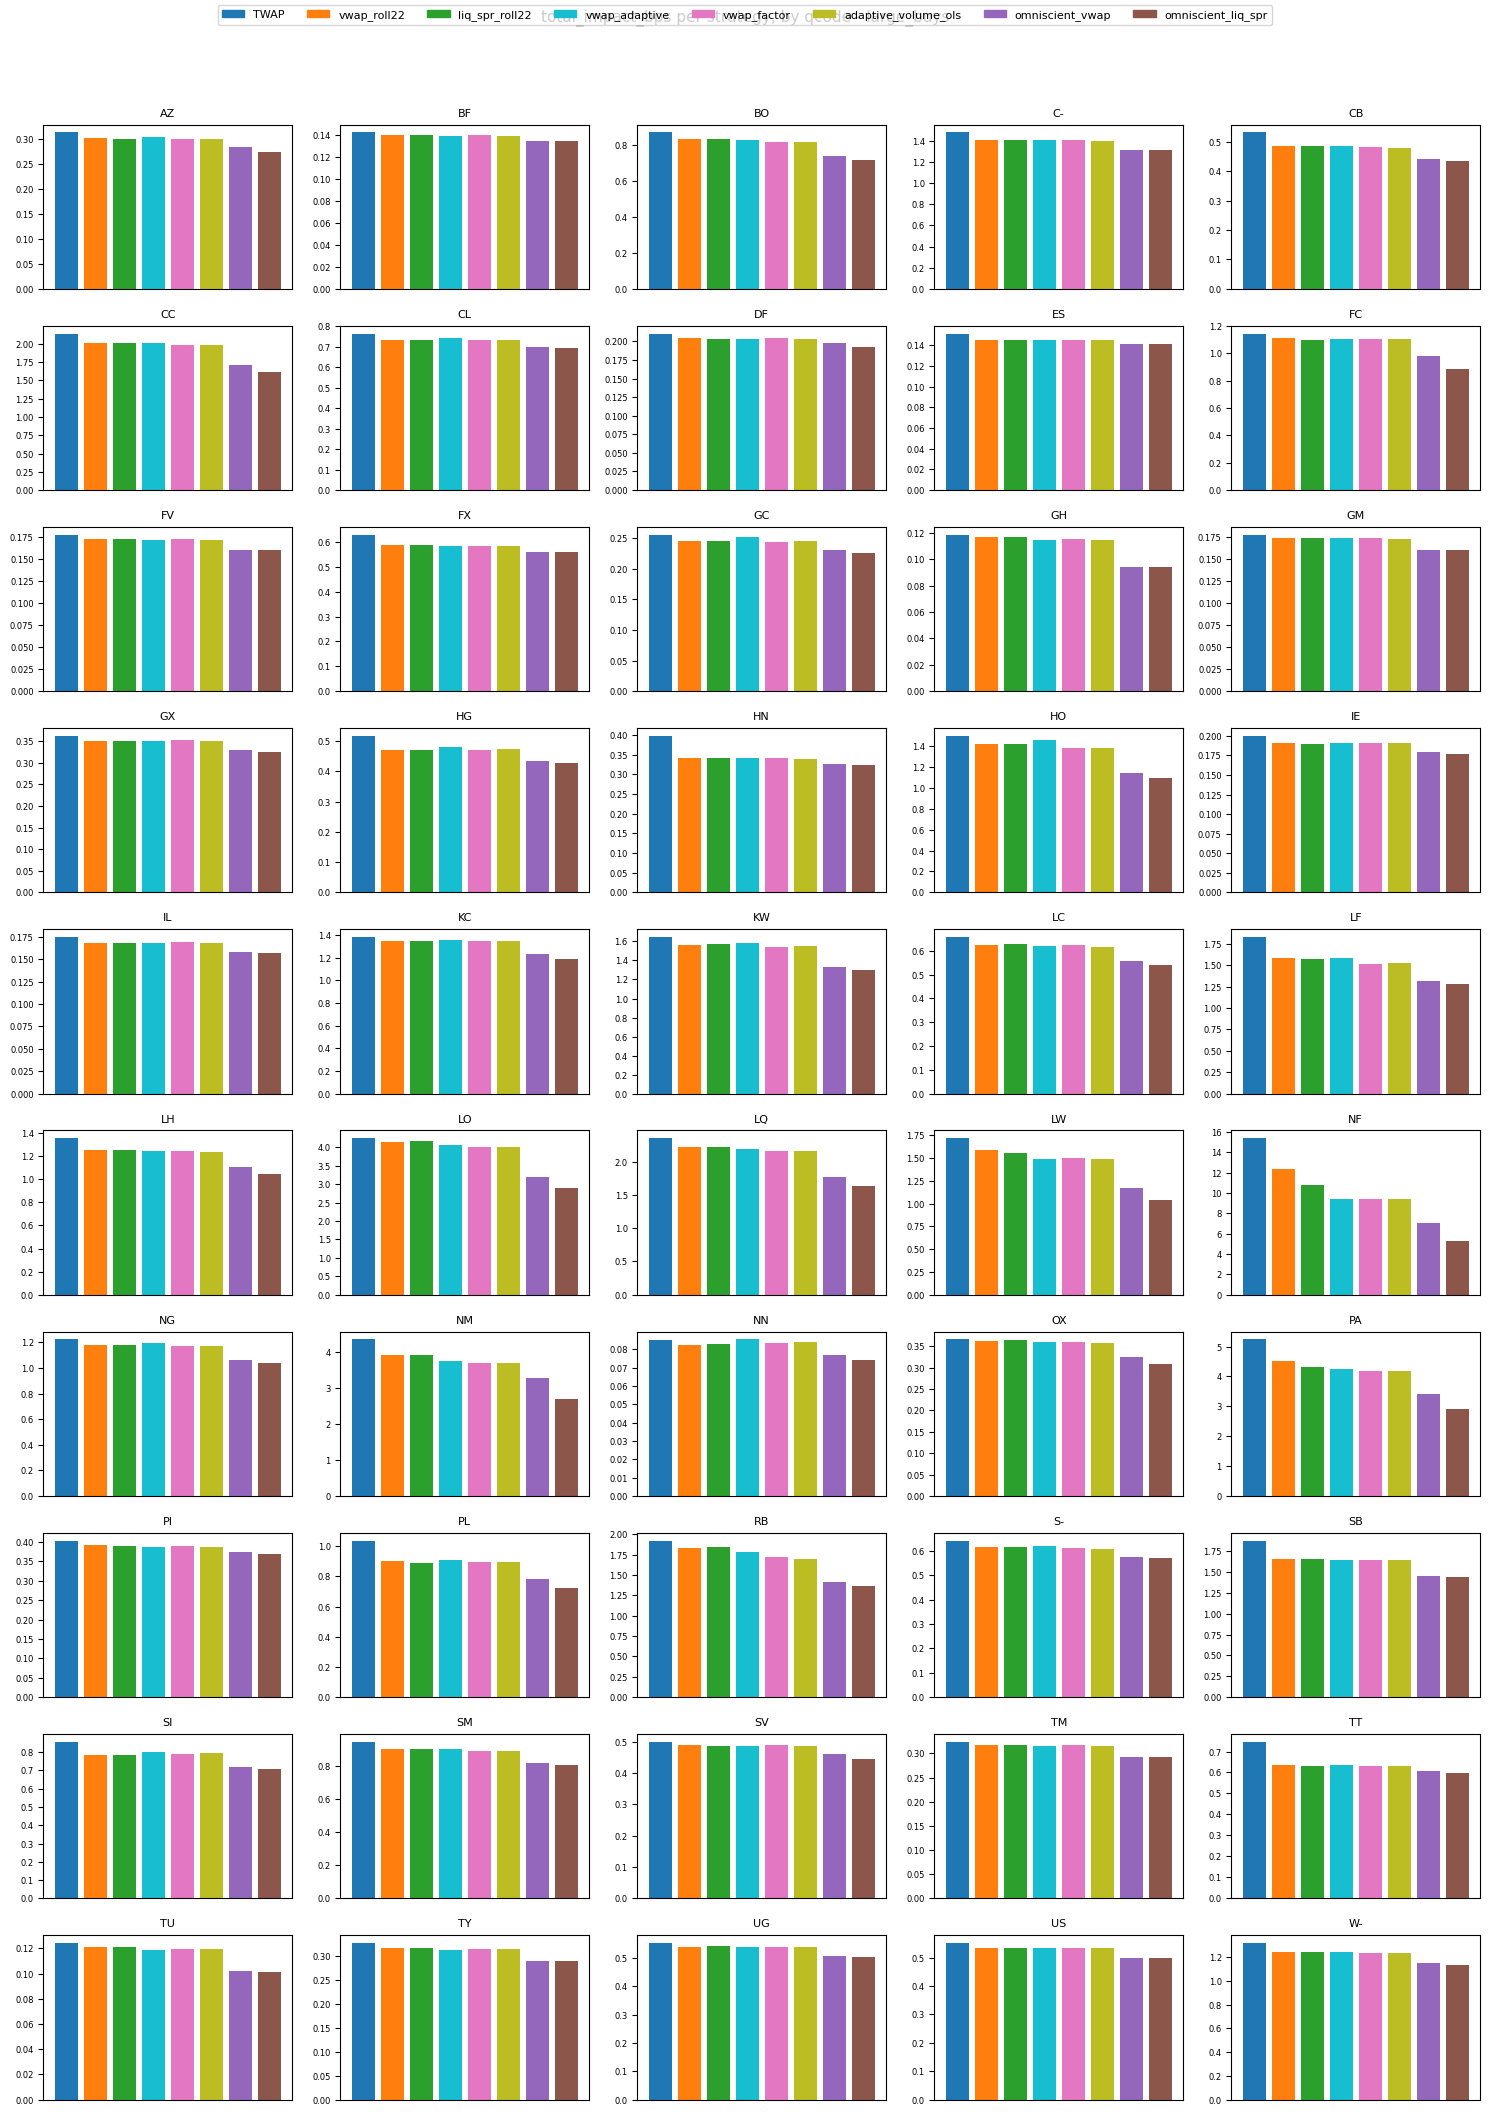

In [28]:
# Per-qcode market-impact bps, one COLUMN per strategy (rows = qcode). METRIC picks
# which notional-weighted order-impact component to show; they add up
# (realised + opportunity = total). Strategies come from _summaries, so the strategy
# count is never hardcoded.
METRIC = "total_impact_bps"        # "total_impact_bps" | "realised_bps" | "opportunity_bps"

_strats = [nm for nm, _ in _summaries]
qcode_impact = (
    pl.concat([asset_impact(s).select("qcode", pl.lit(nm).alias("strategy"),
                                       pl.col(METRIC).alias("v"))
               for nm, s in _summaries])
    .pivot(values="v", index="qcode", on="strategy")
    .select(["qcode", *_strats]).sort("qcode")
)
pl.Config.set_tbl_rows(qcode_impact.height)
print(f"{METRIC} by qcode x strategy ({BUCKET}):")
print(qcode_impact)

# one mini bar chart per qcode: the chosen METRIC across all strategies
_colmap = {name: color for name, _, color in STRATS}
_cmap = plt.get_cmap("tab10")
colors = [_colmap.get(nm, _cmap(i % 10)) for i, nm in enumerate(_strats)]
qcodes = qcode_impact["qcode"].to_list()
nq, nstr = len(qcodes), len(_strats)
ncols = 5
nrows = int(np.ceil(nq / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 2.1 * nrows), squeeze=False)
xpos = np.arange(nstr)
for i, qc in enumerate(qcodes):
    ax = axes[i // ncols][i % ncols]
    vals = [v if v is not None else np.nan
            for v in qcode_impact.filter(pl.col("qcode") == qc).select(_strats).row(0)]
    ax.bar(xpos, vals, color=colors)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(qc, fontsize=8)
    ax.set_xticks([])
    ax.tick_params(axis="y", labelsize=6)
for i in range(nq, nrows * ncols):            # hide unused axes
    axes[i // ncols][i % ncols].axis("off")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors]
fig.legend(handles, _strats, loc="upper center", ncol=min(nstr, 8), fontsize=8)
fig.suptitle(f"{METRIC} per strategy, by qcode - {BUCKET}", y=1.005, fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### Market-impact bps by TWAP-impact **tier** × strategy

Instead of asset class, qcodes are bucketed into four tiers by their **baseline TWAP** `total_impact_bps` (hardcoded from the full-run TWAP results): `<0.25` don't-bother, `0.25–1` static-fine, `1–2.5` dynamic-sweet-spot, `>2.5` danger-zone. Within each tier the metric is **notional-weighted / pooled** (Σ cost / Σ notional across the tier's orders — not an average of per-qcode bps). Rationale: low-impact names (tier 1, mostly bond futures) have little headroom, so dynamic-optimisation effort should target the higher tiers. `METRIC_TIER` switches total / realised / opportunity.

tier,TWAP,vwap_roll22,liq_spr_roll22,vwap_adaptive,vwap_factor,adaptive_volume_ols,omniscient_vwap,omniscient_liq_spr
str,f64,f64,f64,f64,f64,f64,f64,f64
"""1 (Low Impact): <0.25""",0.145986,0.141663,0.141601,0.14133,0.141538,0.141154,0.132094,0.131409
"""2 (Medium Impact): 0.25-1""",0.438971,0.418978,0.419066,0.417929,0.417686,0.416851,0.390527,0.388741
"""3 (High Impact): 1-2.5""",1.57111,1.466185,1.462269,1.464539,1.426677,1.426217,1.245538,1.212735
"""4 (Very High Impact): >2.5""",5.784832,5.034665,4.814093,4.545036,4.499806,4.497659,3.714632,3.070067


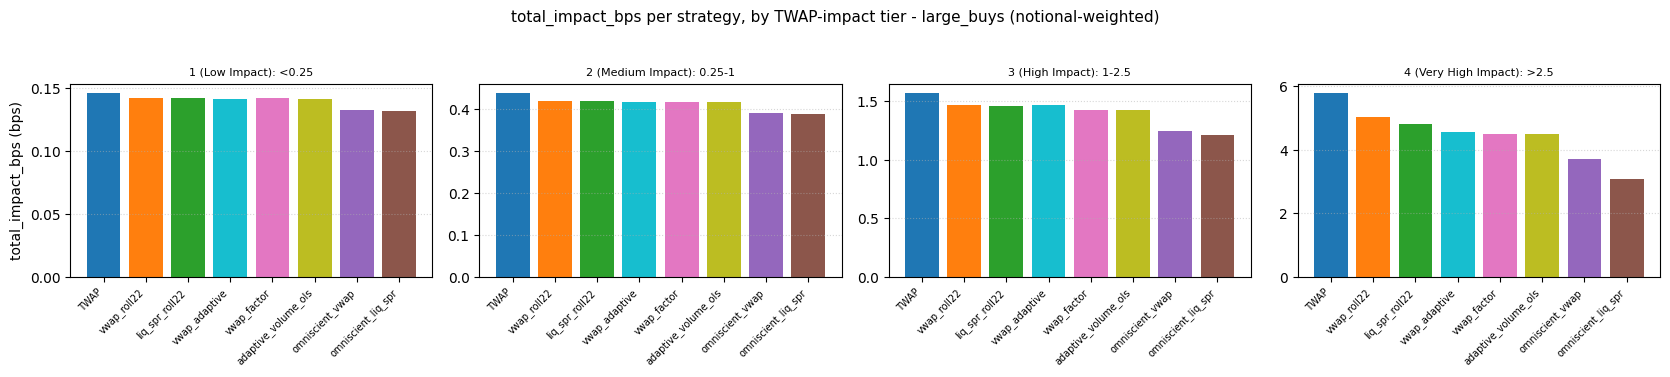

In [29]:
# Group qcodes into IMPACT TIERS (hardcoded from each asset's baseline TWAP
# total_impact_bps), then pool the order-impact metric within each tier -- notional-
# weighted (asset_impact sums $ cost and $ notional across the tier's orders, then
# divides; NOT an average of per-qcode bps). Rationale: deep-liquidity tier-1 names
# (mostly bond futures) have little headroom, so dynamic optimisation should focus
# on the higher tiers.
METRIC_TIER = "total_impact_bps"     # "total_impact_bps" | "realised_bps" | "opportunity_bps"

IMPACT_TIERS = {
    "1 (Low Impact): <0.25":       ["NN","GH","TU","BF","ES","IL","FV","GM","IE","DF"],
    "2 (Medium Impact): 0.25-1":       ["GC","AZ","TM","TY","GX","OX","HN","PI","SV","HG","CB",
                                      "US","UG","FX","S-","LC","TT","CL","SI","BO","SM"],
    "3 (High Impact): 1-2.5": ["PL","FC","NG","W-","LH","KC","C-","HO","KW","LW","LF",
                                      "SB","RB","CC","LQ"],
    "4 (Very High Impact): >2.5":         ["LO","NM","PA","NF"],
}
_tier_map = pl.DataFrame({"qcode": [q for qs in IMPACT_TIERS.values() for q in qs],
                          "tier":  [t for t, qs in IMPACT_TIERS.items() for _ in qs]})
_strats = [nm for nm, _ in _summaries]

tier_impact = (
    pl.concat([
        asset_impact(s.join(_tier_map, on="qcode", how="inner"), by="tier")
          .select("tier", pl.lit(nm).alias("strategy"), pl.col(METRIC_TIER).alias("v"))
        for nm, s in _summaries
    ])
    .pivot(values="v", index="tier", on="strategy")
    .select(["tier", *_strats]).sort("tier")
)
display(tier_impact)   # dataframe view (copy-friendly for Excel), not text print

# one bar chart per tier: chosen metric across all strategies
_colmap = {name: color for name, _, color in STRATS}
_cmap = plt.get_cmap("tab10")
colors = [_colmap.get(nm, _cmap(i % 10)) for i, nm in enumerate(_strats)]
tiers = tier_impact["tier"].to_list()
nt, nstr = len(tiers), len(_strats)
fig, axes = plt.subplots(1, nt, figsize=(4.2 * nt, 3.8), squeeze=False)
xpos = np.arange(nstr)
for i, t in enumerate(tiers):
    ax = axes[0][i]
    vals = [v if v is not None else np.nan
            for v in tier_impact.filter(pl.col("tier") == t).select(_strats).row(0)]
    ax.bar(xpos, vals, color=colors)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(t, fontsize=8)
    ax.set_xticks(xpos); ax.set_xticklabels(_strats, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel(f"{METRIC_TIER} (bps)" if i == 0 else "")
    ax.grid(axis="y", ls=":", alpha=0.5)
fig.suptitle(f"{METRIC_TIER} per strategy, by TWAP-impact tier - {BUCKET} (notional-weighted)", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Paired significance tests — market-impact bps by tier

For every **strategy pair** and every impact tier, orders are paired by `order_id` and a paired t-test (`ttest_rel`) is run on the **per-order** total-impact bps (`order_impact / impact_notional * 1e4`). Each tier gives an N×N matrix (t-stat / p-value / paired n); colour = significance band (green `p<0.01`, orange `0.01≤p<0.05`, grey n.s.). H0: mean pairwise diff = 0.

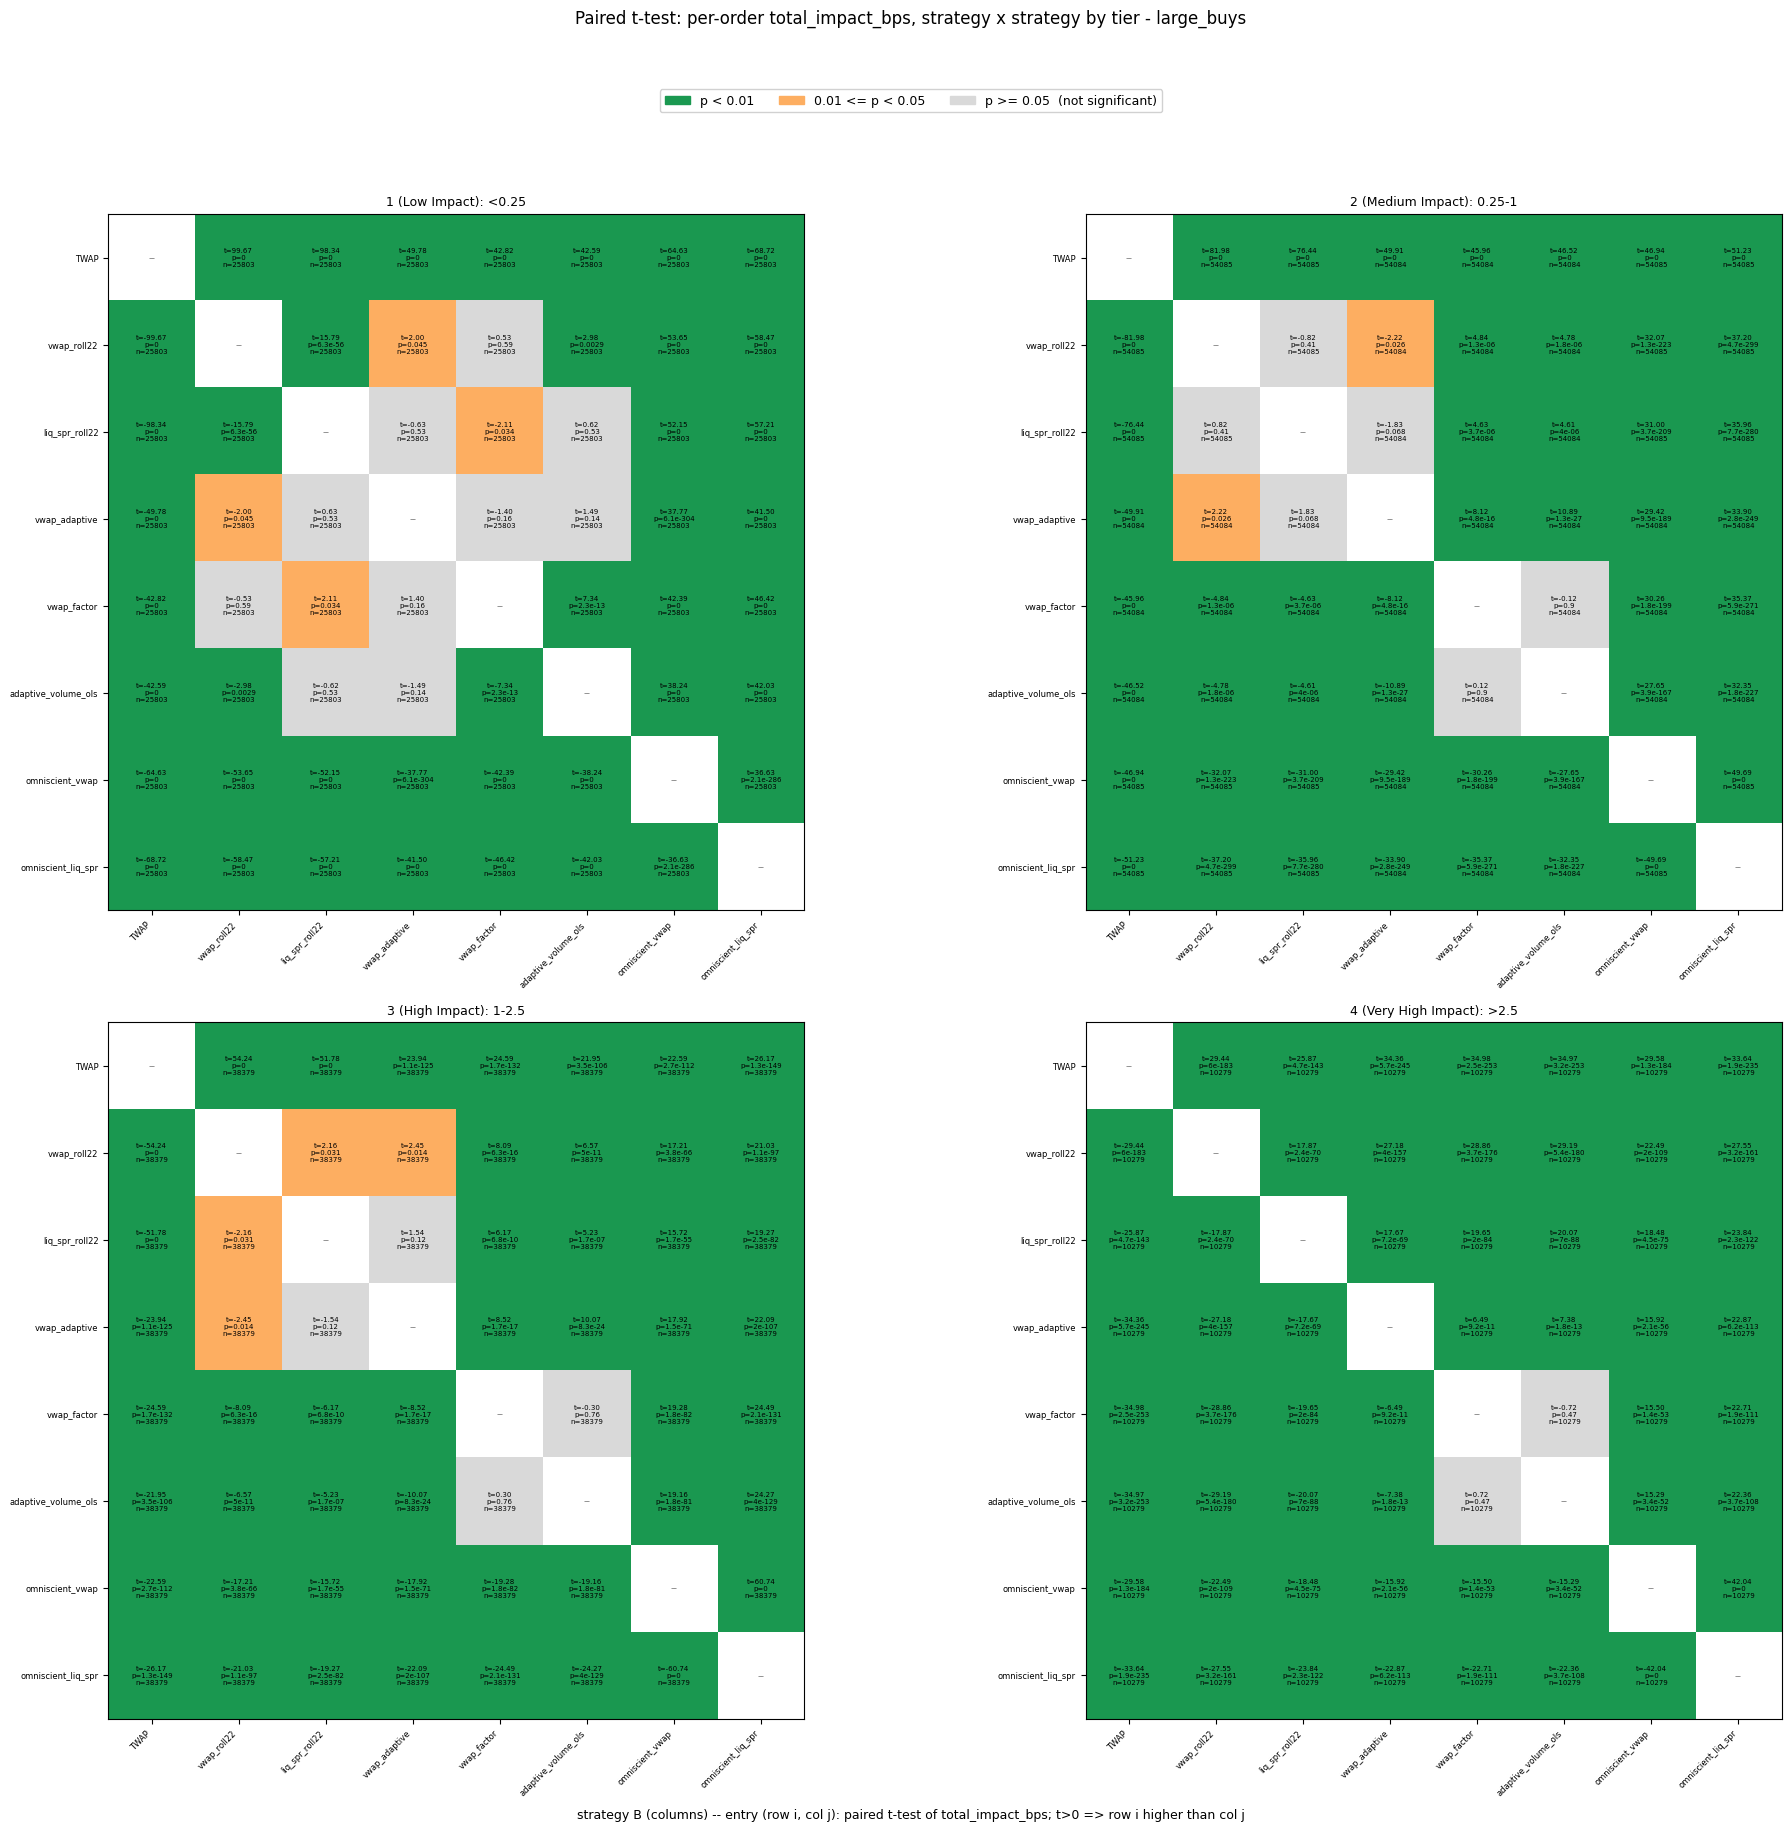

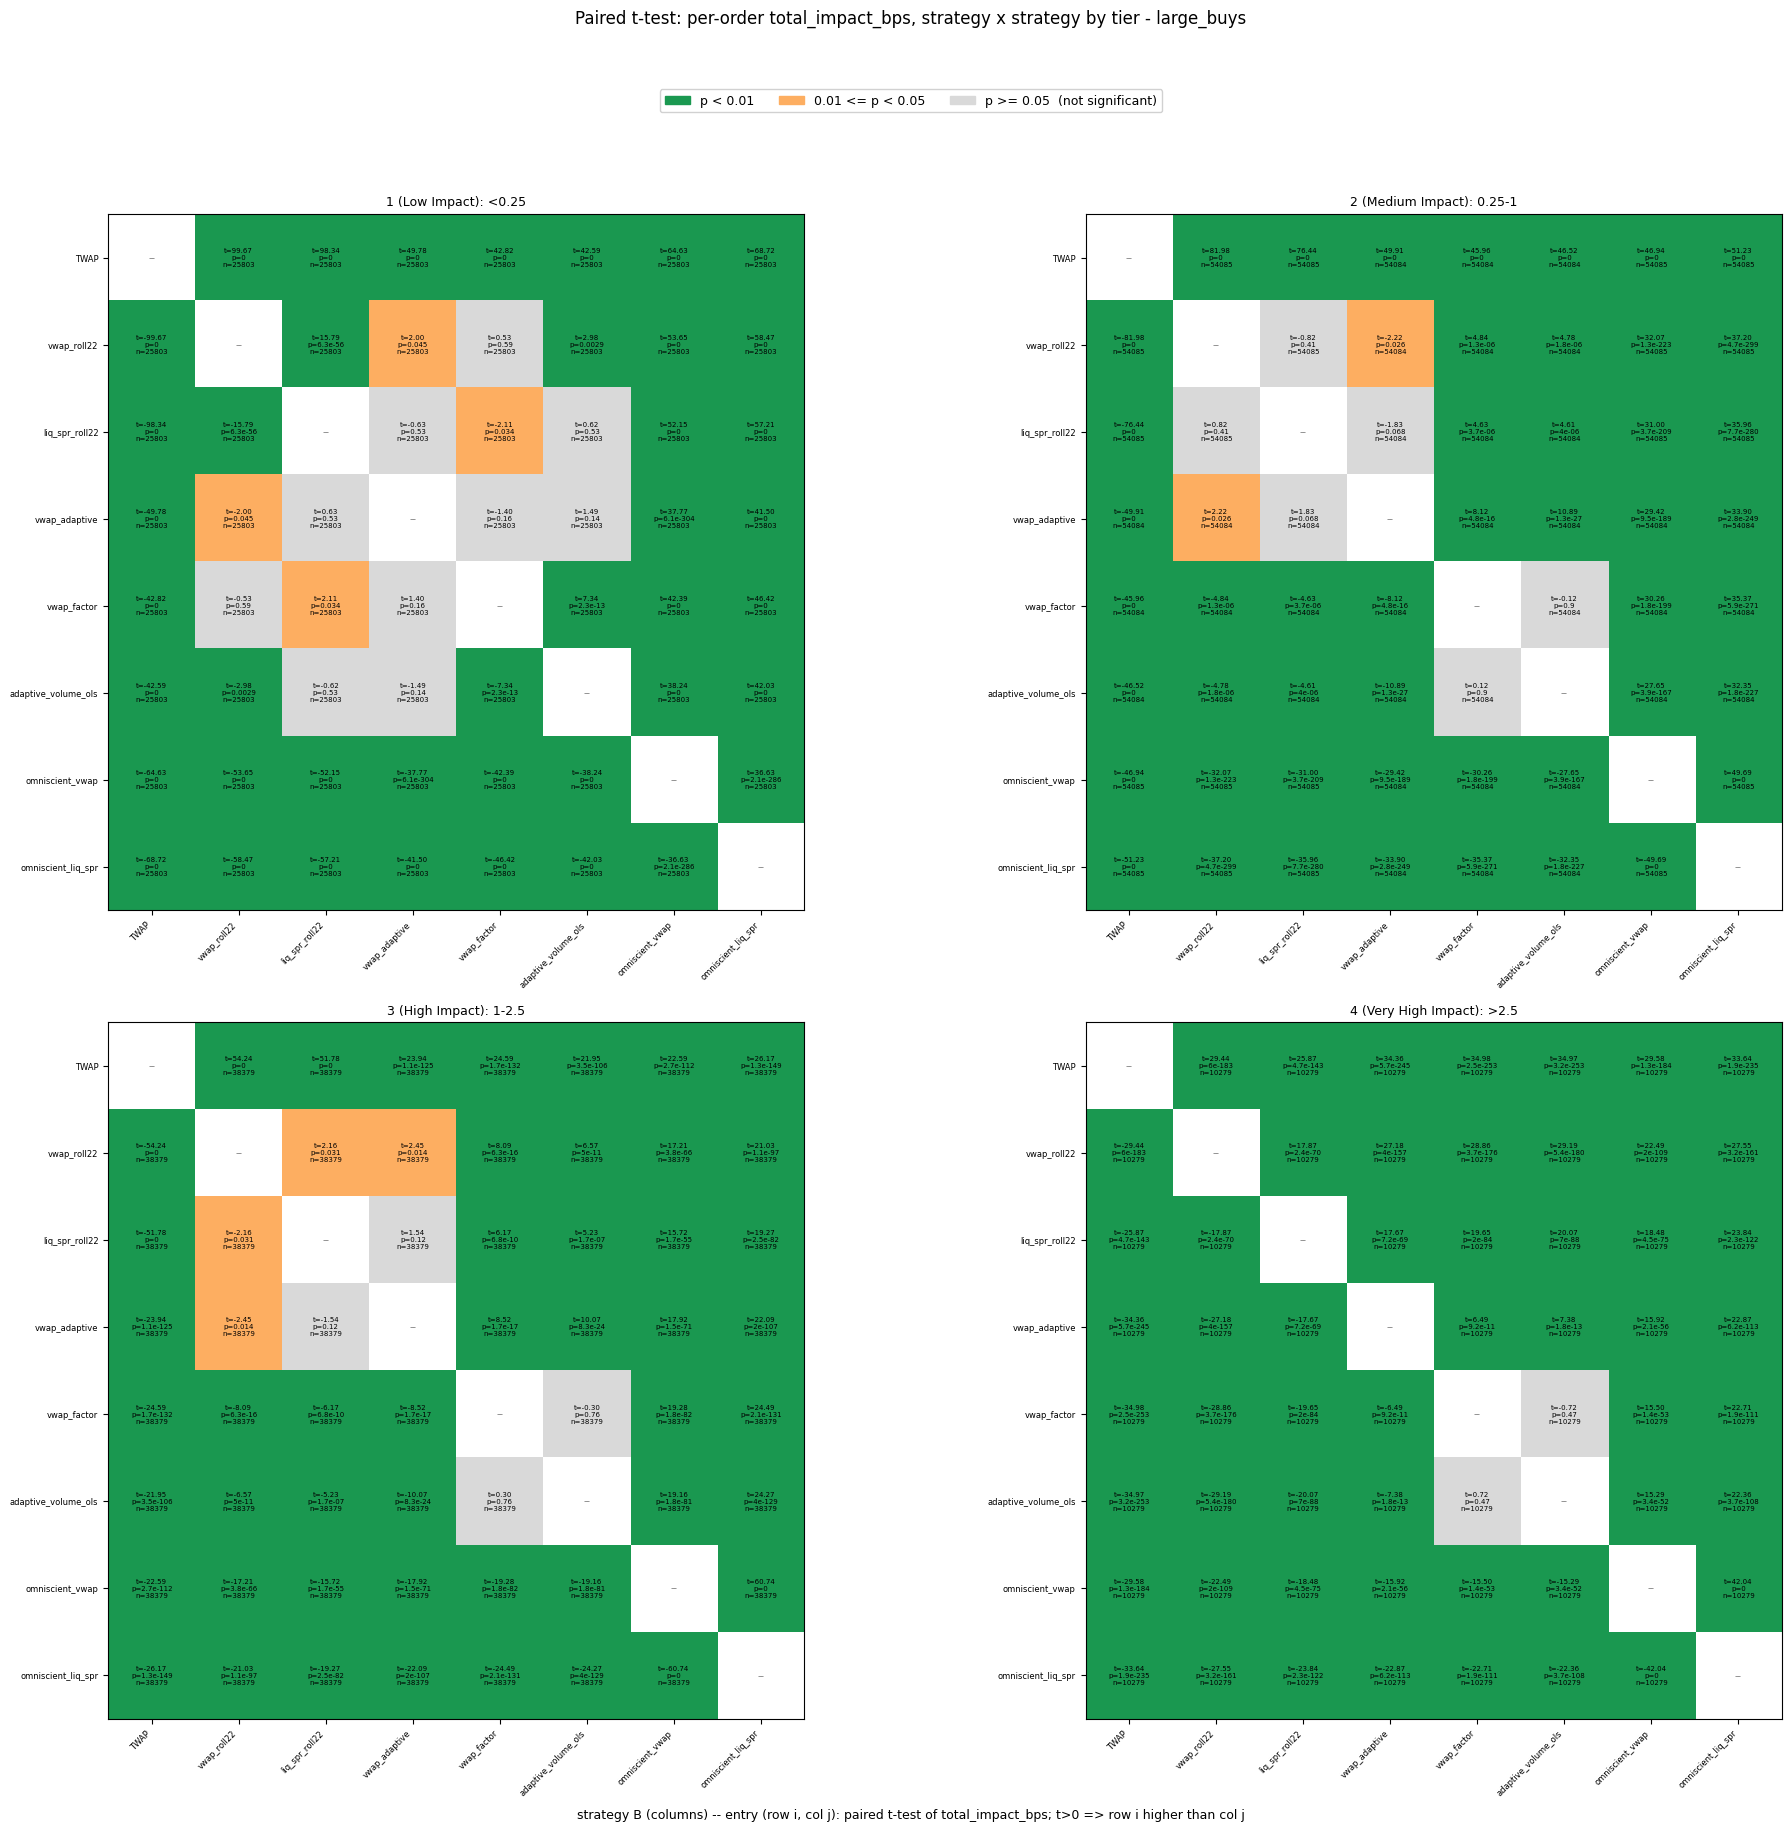

In [30]:
# Paired t-test of the per-order total-impact bps: within each impact tier, every
# strategy pair's orders are matched on order_id and tested with a paired t-test
# (H0: mean pairwise difference = 0). One NxN matrix per tier; cell colour = p-value
# band (green p<0.01, orange p<0.05, grey n.s.), text = t / p / paired n. N is read
# from _summaries, never hardcoded. Implementation: paired_impact_ttest in execution.py.
paired_impact_ttest(_summaries, IMPACT_TIERS, bucket=BUCKET)


### Participation-rate CV by TWAP-impact **tier** × strategy

The participation-dispersion view (weighted participation volatility σ_p and its `CV = σ_p/P`) bucketed into the same four impact tiers. Table = **mean CV** per tier × strategy; below, one panel per tier plots each strategy's mean CV with **± 1 std** error bars (spread of CV across that tier's orders). Lower = flatter, more VWAP-like participation.

tier,TWAP,vwap_roll22,liq_spr_roll22,vwap_adaptive,vwap_factor,adaptive_volume_ols,omniscient_vwap,omniscient_liq_spr
str,f64,f64,f64,f64,f64,f64,f64,f64
"""1 (Low Impact): <0.25""",0.83225,0.672297,0.687489,0.658688,0.67928,0.657222,0.003168,0.13207
"""2 (Medium Impact): 0.25-1""",0.877713,0.598546,0.626345,0.578688,0.585917,0.564098,0.01086,0.201203
"""3 (High Impact): 1-2.5""",1.028073,0.747033,0.793285,0.731573,0.726115,0.706907,0.046903,0.40225
"""4 (Very High Impact): >2.5""",1.435409,1.175485,1.280454,1.148361,1.141967,1.126682,0.172615,0.98482


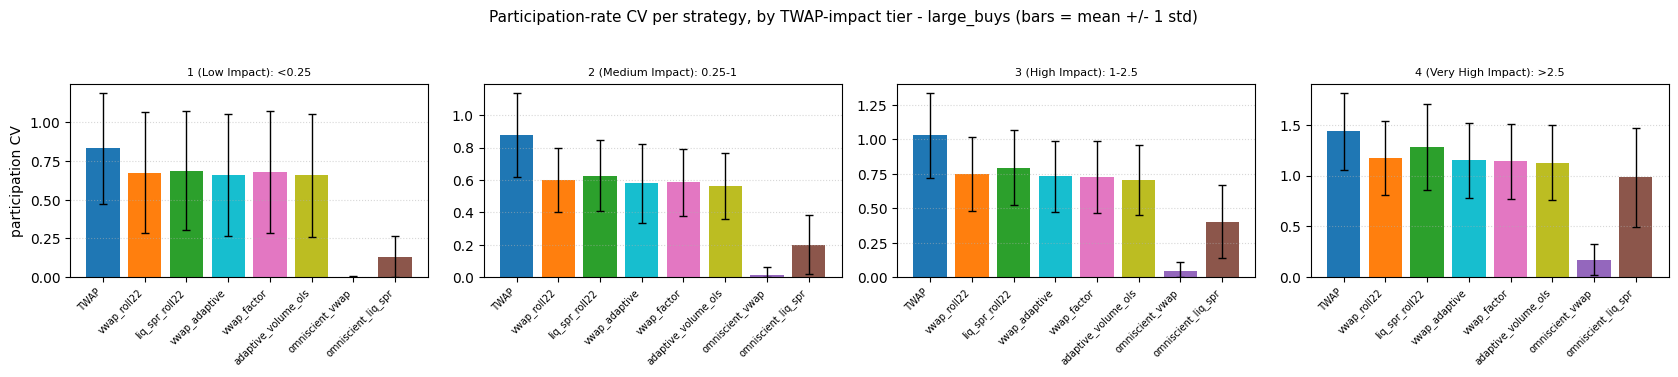

In [31]:
# Participation-rate CV by TWAP-impact tier x strategy. Per strategy: take the
# per-order participation CV (participation_dispersion on the per-bin fills), tag each
# order's qcode with its IMPACT_TIERS bucket, and summarise per (tier, strategy).
# Table = mean CV; 4 plots = mean CV +/- 1 std across orders, one panel per tier.
_tier_map = pl.DataFrame({"qcode": [q for qs in IMPACT_TIERS.values() for q in qs],
                          "tier":  [t for t, qs in IMPACT_TIERS.items() for _ in qs]})
_strats = [nm for nm, _ in _fills]
_cv = pl.concat([
    participation_dispersion(f).join(_tier_map, on="qcode", how="inner")
      .select("tier", pl.lit(nm).alias("strategy"), "participation_cv")
    for nm, f in _fills
]).filter(pl.col("participation_cv").is_not_null() & pl.col("participation_cv").is_not_nan())
_cvstats = (_cv.group_by("tier", "strategy")
            .agg(pl.col("participation_cv").mean().alias("mean_cv"),
                 pl.col("participation_cv").std().alias("std_cv"),
                 pl.len().alias("n"))
            .sort("tier", "strategy"))
cv_tier = (_cvstats.select("tier", "strategy", "mean_cv")
           .pivot(values="mean_cv", index="tier", on="strategy")
           .select(["tier", *_strats]).sort("tier"))
pl.Config.set_tbl_rows(cv_tier.height)
display(cv_tier)   # dataframe view (copy-friendly for Excel), not text print

# one panel per tier: mean CV per strategy with +/-1 std error bars (clipped at 0)
_colmap = {name: color for name, _, color in STRATS}
_cmap = plt.get_cmap("tab10")
colors = [_colmap.get(nm, _cmap(i % 10)) for i, nm in enumerate(_strats)]
tiers = cv_tier["tier"].to_list()
nt, nstr = len(tiers), len(_strats)
fig, axes = plt.subplots(1, nt, figsize=(4.2 * nt, 3.8), squeeze=False)
xpos = np.arange(nstr)
for i, t in enumerate(tiers):
    ax = axes[0][i]
    means, errs = [], []
    for nm in _strats:
        r = _cvstats.filter((pl.col("tier") == t) & (pl.col("strategy") == nm))
        means.append(r["mean_cv"][0] if r.height else np.nan)
        errs.append(r["std_cv"][0] if r.height else np.nan)
    means = np.array(means, float)
    errs = np.nan_to_num(np.array(errs, float))
    ax.bar(xpos, means, yerr=[np.minimum(errs, means), errs], color=colors,
           capsize=3, error_kw={"elinewidth": 1})
    ax.set_title(t, fontsize=8)
    ax.set_xticks(xpos); ax.set_xticklabels(_strats, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("participation CV" if i == 0 else "")
    ax.grid(axis="y", ls=":", alpha=0.5)
fig.suptitle(f"Participation-rate CV per strategy, by TWAP-impact tier - {BUCKET} "
             f"(bars = mean +/- 1 std)", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Paired significance tests — participation CV by tier

Same paired-t-test design, per-order metric = participation CV. Run the market-impact test cell above first (it defines `_paired_ttest_panels` and `_tier_map`).

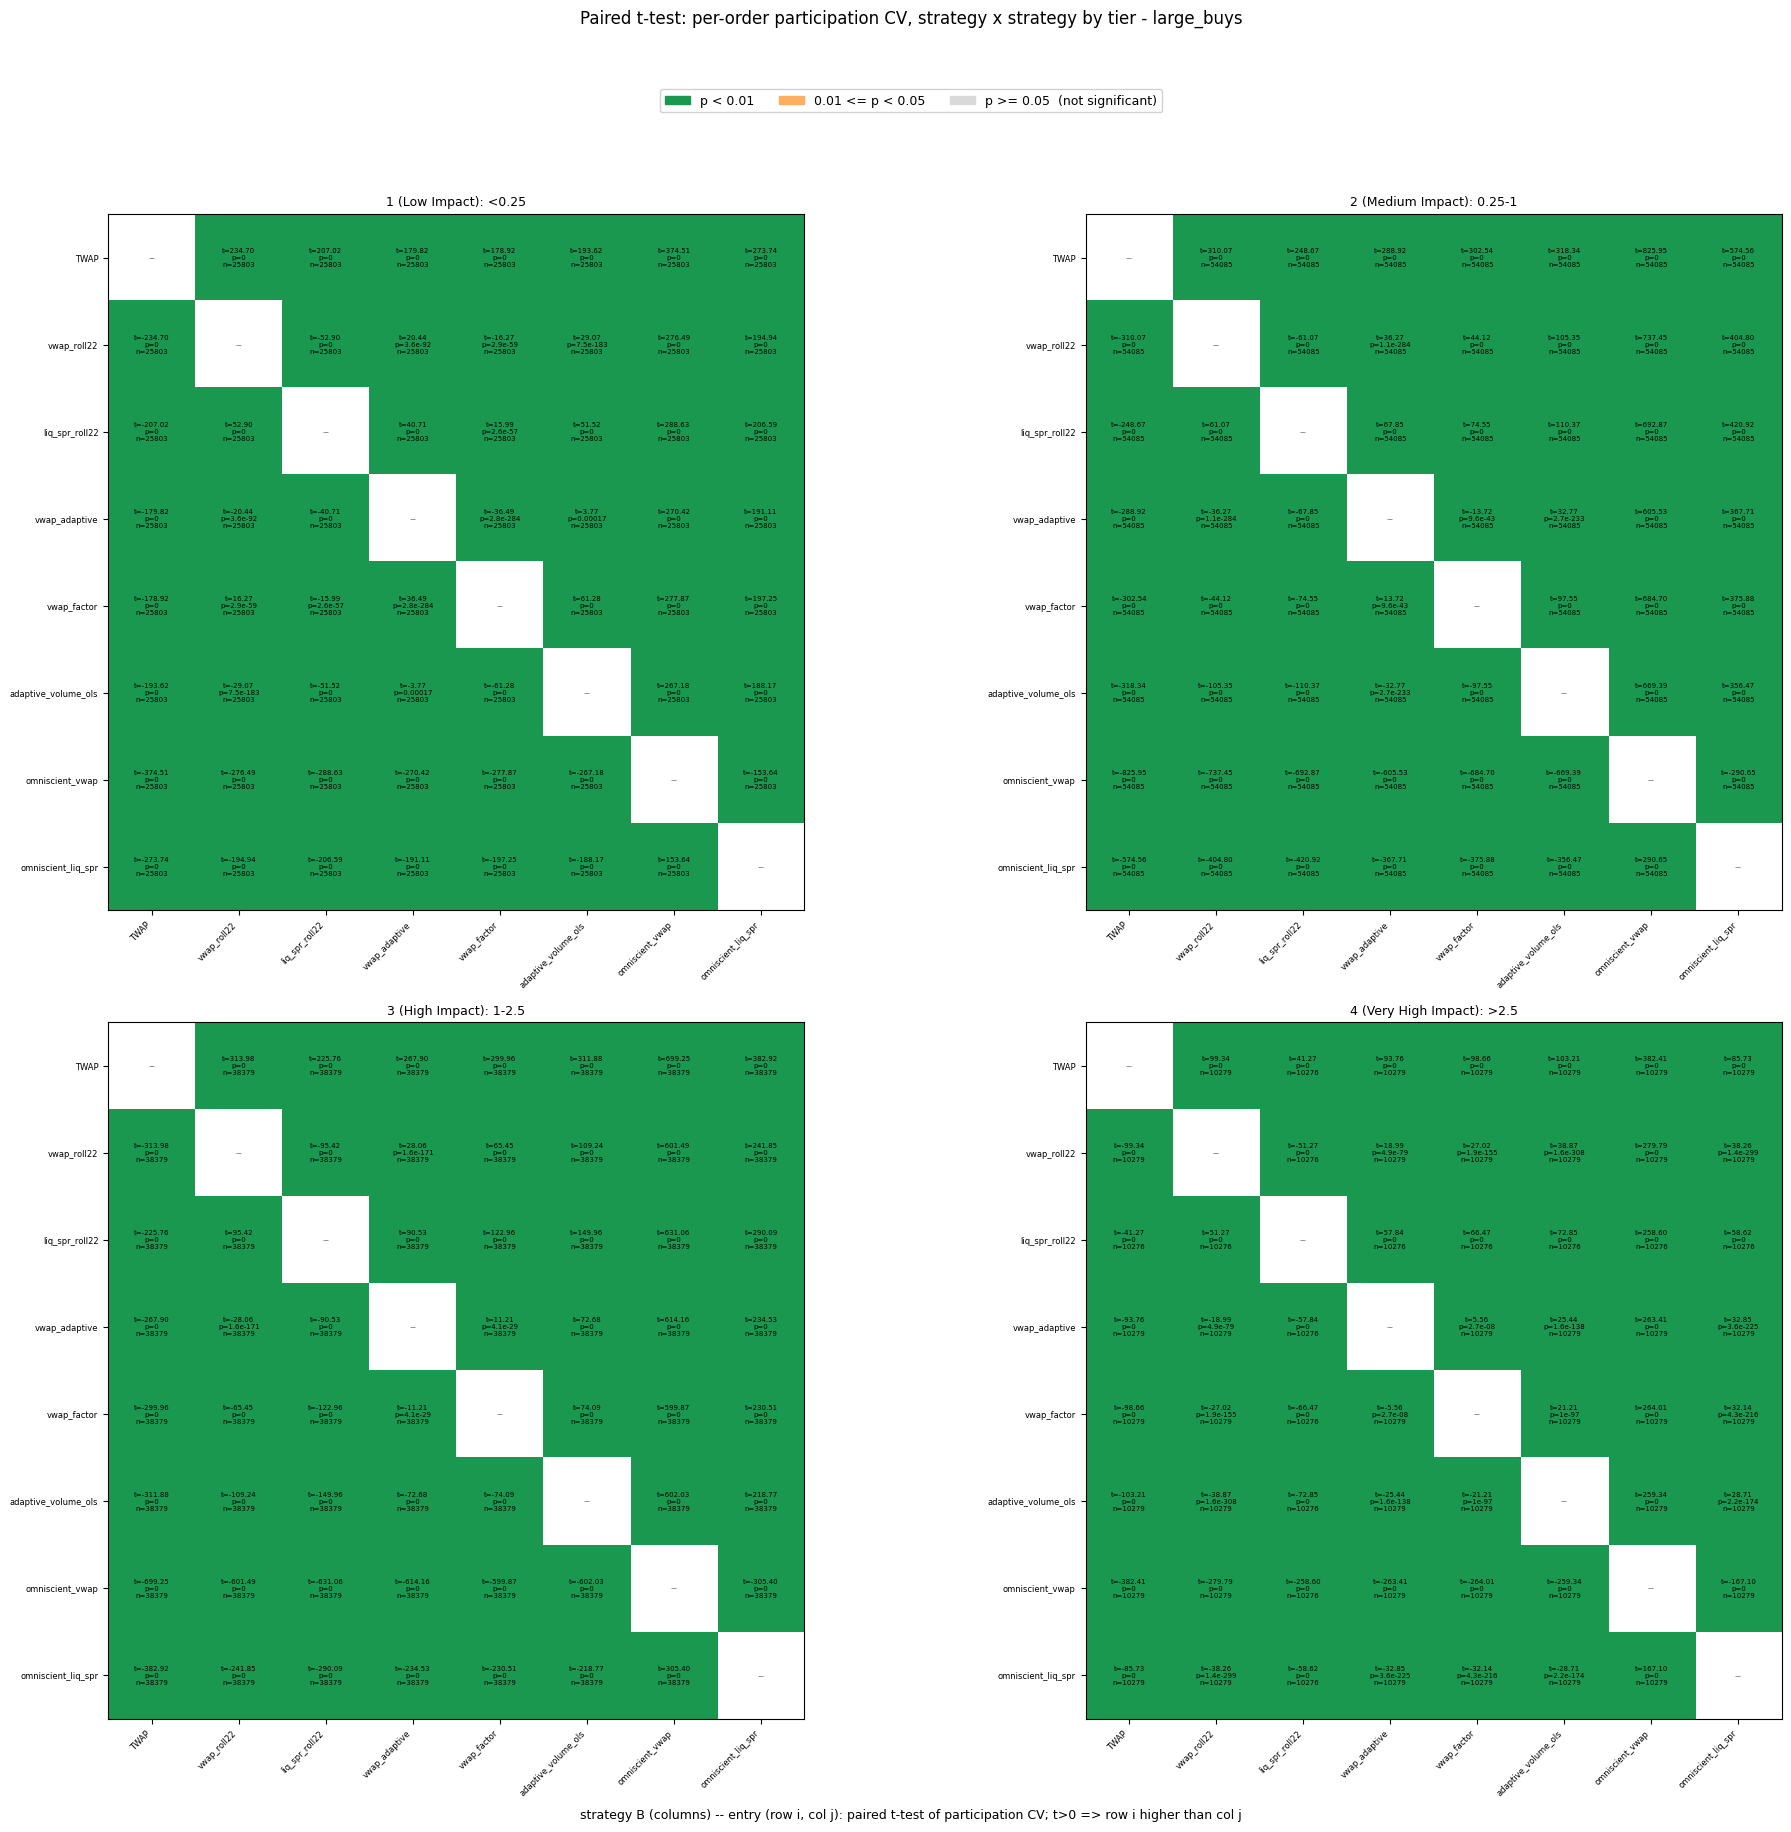

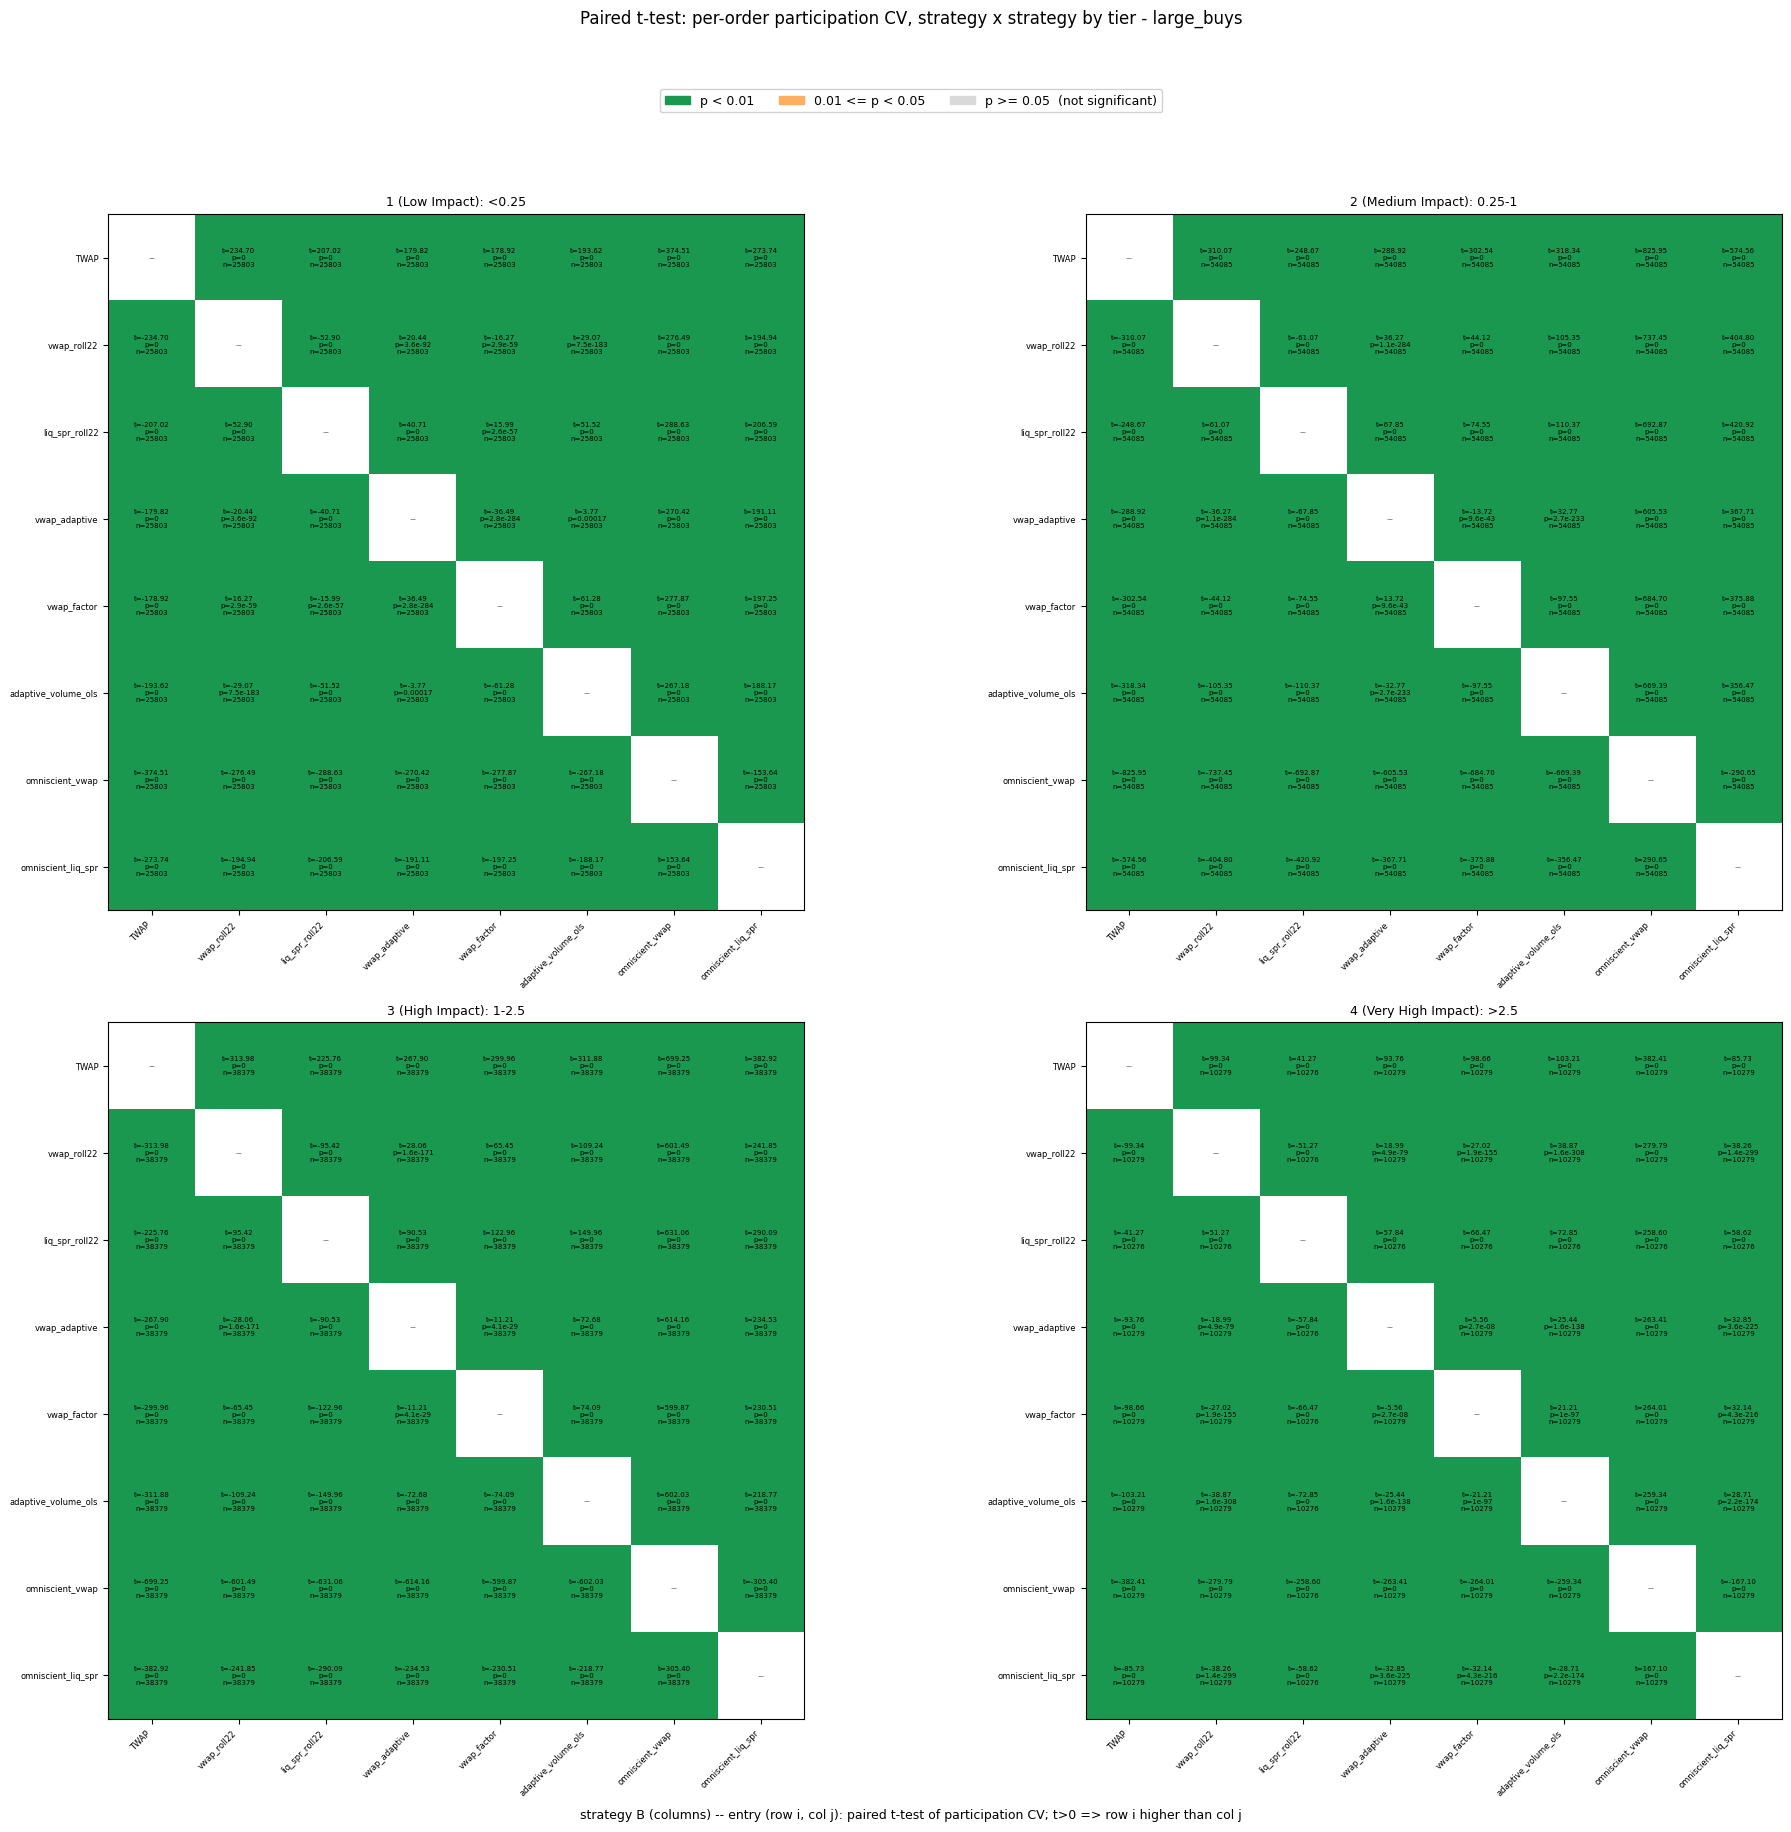

In [32]:
# Same paired-t-test design, per-order metric = participation CV (participation_dispersion).
# Implementation: paired_participation_ttest in execution.py.
paired_participation_ttest(_fills, IMPACT_TIERS, bucket=BUCKET)
